KNN데이터셋 EDA(Exploratory Data Analysis)  
작성자 : Sim Sang Il  
최종 업데이트 날짜 : 2025/02/06  

In [232]:
# import library 
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ssi_utils import bmi_zscore, WHO_bmi_zscore

In [210]:
# definition path & filename

data_path = "F:/data/knn"
data_file = "knn_dataset.csv"
data = pd.read_csv(os.path.join(data_path, data_file)) # 18,127건


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_67552\2063574527.py:5: DtypeWarning: Columns (22,90,102,110,111,117,132,139,162,201,205,215,217) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(data_path, data_file)) # 18,127건


eCRF분류 별로 데이터 확인해보기
---

## Demographics

In [211]:
# 성별, 출생년도
demo_columns = ["sex_sys_val", "birthdt"]
demographics = data[demo_columns]
demographics['birthyear'] = pd.to_datetime(demographics['birthdt']).dt.year

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_67552\4073344523.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demographics['birthyear'] = pd.to_datetime(demographics['birthdt']).dt.year


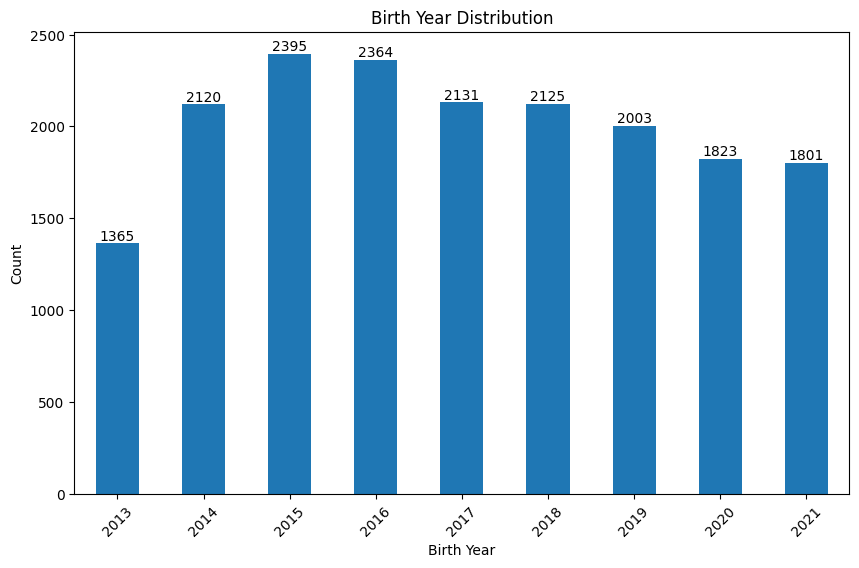

In [212]:
# value_counts() 결과를 정렬합니다.
counts = demographics['birthyear'].value_counts().sort_index()

# pandas의 plot() 함수를 사용하여 바 차트를 생성합니다.
ax = counts.plot(kind='bar', figsize=(10, 6))

# 각 막대 위에 count 값을 표시합니다.
for p in ax.patches:
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.xlabel('Birth Year')
plt.ylabel('Count')
plt.title('Birth Year Distribution')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 1=Male|2=Female|3=Unknown 
demographics['sex_sys_val'].value_counts()

sex_sys_val
1    9064
2    9057
3       6
Name: count, dtype: int64

sex_sys_val
1    9064
2    9057
3       6
Name: count, dtype: int64

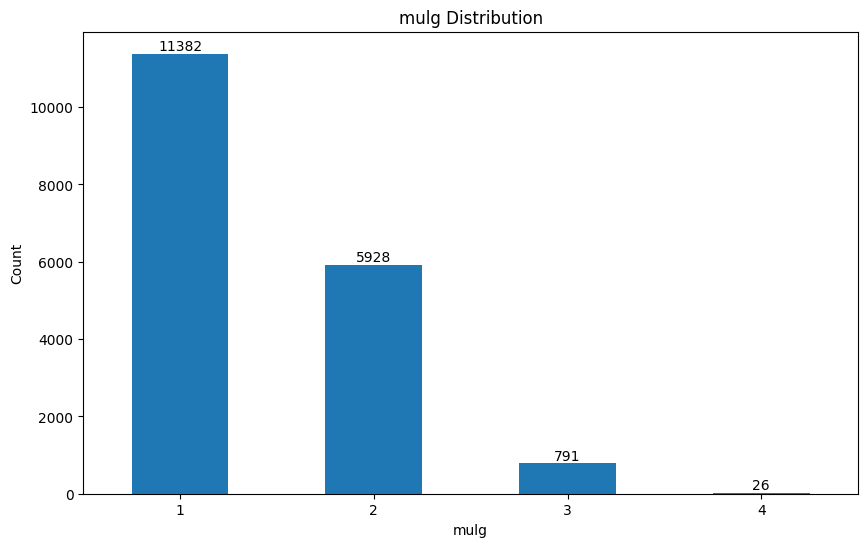

In [ ]:
# 단태(Singleton)/다태(Multiple gestation) 정보
# 1=Singleton|2=Twin|3=Triplet|4=Quadruplet 이상

counts = data["mulg"].value_counts()

# pandas의 plot() 함수를 사용하여 바 차트를 생성합니다.
ax = counts.plot(kind='bar', figsize=(10, 6))

# 각 막대 위에 count 값을 표시합니다.
for p in ax.patches:
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')

plt.xlabel('mulg')
plt.ylabel('Count')
plt.title('mulg Distribution')
plt.xticks(rotation=0)
plt.show()

### 재태연령에 따른 BMI 분포 확인

In [ ]:
bmi_data = data[['bwei', 'bhei', 'gagew', 'sex_sys_val']]
print(bmi_data.shape) # (18127, 2)

bmi_data[["bmi", "zscore"]] = bmi_data.apply(
    lambda row: pd.Series(
        bmi_zscore(row["bwei"], row["bhei"], row["gagew"], row["sex_sys_val"])
    ), 
    axis=1
)


bmi_data = bmi_data.dropna(axis = 0)
print(bmi_data.shape) # (17094, 2)
bmi_data.isnull().sum()

(18127, 4)
(16470, 6)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_67552\3961996170.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bmi_data[["bmi", "zscore"]] = bmi_data.apply(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_67552\3961996170.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bmi_data[["bmi", "zscore"]] = bmi_data.apply(


bwei           0
bhei           0
gagew          0
sex_sys_val    0
bmi            0
zscore         0
dtype: int64

In [ ]:
# bmi_data['bmi'] = (bmi_data['bwei'] / bmi_data['bhei']**2) * 10
bmi_data.head()

,bwei,bhei,gagew,sex_sys_val,bmi,zscore
0,1350,39.0,30,1,8.875740,-0.028606
1,790,34.3,26,1,6.714889,-1.032871
2,1400,39.0,29,1,9.204471,0.731970
3,1340,36.0,29,1,10.339506,1.802777
4,1240,42.0,27,1,7.029478,-0.976796


In [ ]:
bmi_data_m = bmi_data[bmi_data['sex_sys_val'] == 1]
bmi_data_f = bmi_data[bmi_data['sex_sys_val'] == 2]

(8218, 6)


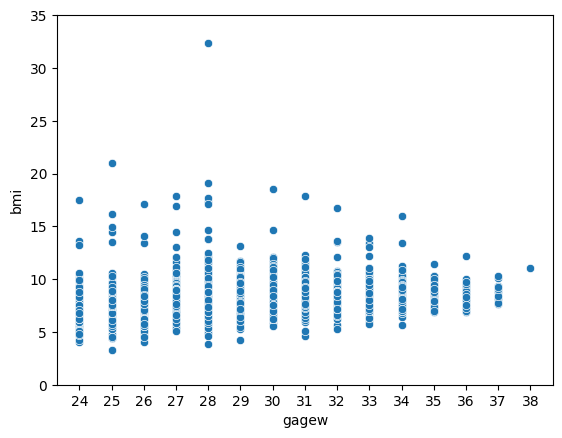

In [ ]:
# BMI 분포 그리기 - 남성
print(bmi_data_m.shape)
sns.scatterplot(x = 'gagew', y = 'bmi', data = bmi_data_m)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(bmi_data_m['gagew'].min(), bmi_data_m['gagew'].max() + 1, 1))
plt.yticks(np.arange(0, bmi_data_m['bmi'].max() + 6, 5))
plt.show()

In [ ]:
# BMI 분포 그리기 - 여성
print(bmi_data_f.shape)
sns.scatterplot(x = 'gagew', y = 'bmi', data = bmi_data_f)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(bmi_data_f['gagew'].min(), bmi_data_f['gagew'].max() + 1, 1))
plt.yticks(np.arange(0, bmi_data_f['bmi'].max() + 6, 5))
plt.show()

(8252, 6)


KeyboardInterrupt: 

In [ ]:
# 남성 percentile BMI
# groupby + agg()를 이용해 한 번에 표로 만들기
df_stats = (
    bmi_data_m.groupby("gagew")["bmi"]
      .agg(
          n      = "count",          # 개수
          mean   = "mean",           # 평균
          median = "median",         # 중앙값
          p3  = lambda x: x.quantile(0.03),
          p10 = lambda x: x.quantile(0.10),
          p25 = lambda x: x.quantile(0.25),
          p50 = lambda x: x.quantile(0.50),
          p75 = lambda x: x.quantile(0.75),
          p90 = lambda x: x.quantile(0.90),
          p97 = lambda x: x.quantile(0.97)
      )
      .reset_index()
)

# 표 출력
print(df_stats)

    gagew     n       mean     median         p3        p10        p25  \
0      24   456   7.055365   6.983124   5.367945   6.009944   6.483509   
1      25   661   7.397241   7.333333   5.844525   6.336088   6.816568   
2      26   767   7.683973   7.673469   5.989812   6.521918   7.101316   
3      27   988   8.070141   8.035062   6.235466   6.851519   7.428571   
4      28  1195   8.325596   8.250000   6.426658   7.105669   7.642171   
5      29  1206   8.487784   8.492442   6.746138   7.359339   7.910606   
6      30   952   8.532649   8.565572   6.775510   7.278860   7.937252   
7      31   684   8.513855   8.518006   6.819657   7.415777   7.944930   
8      32   490   8.503116   8.446712   6.846366   7.377539   7.956687   
9      33   338   8.608915   8.533267   7.107704   7.595301   8.062500   
10     34   260   8.667572   8.721972   7.172332   7.526860   8.119373   
11     35   151   8.716606   8.725762   7.312858   7.812500   8.210005   
12     36    57   8.576024   8.562500 

In [ ]:
# 여성 percentile BMI
# groupby + agg()를 이용해 한 번에 표로 만들기
df_stats = (
    bmi_data_f.groupby("gagew")["bmi"]
      .agg(
          n      = "count",          # 개수
          mean   = "mean",           # 평균
          median = "median",         # 중앙값
          p3  = lambda x: x.quantile(0.03),
          p10 = lambda x: x.quantile(0.10),
          p25 = lambda x: x.quantile(0.25),
          p50 = lambda x: x.quantile(0.50),
          p75 = lambda x: x.quantile(0.75),
          p90 = lambda x: x.quantile(0.90),
          p97 = lambda x: x.quantile(0.97)
      )
      .reset_index()
)

# 표 출력
print(df_stats)

    gagew     n      mean    median        p3       p10       p25       p50  \
0      24   421  6.790150  6.763788  5.125688  5.761317  6.343195  6.763788   
1      25   557  7.182202  7.104592  5.604674  6.122449  6.659729  7.104592   
2      26   717  7.453803  7.477421  5.592756  6.295004  6.861216  7.477421   
3      27   836  7.795378  7.772524  6.004459  6.541929  7.179998  7.772524   
4      28  1087  8.135155  8.131488  6.323005  6.904708  7.492196  8.131488   
5      29  1192  8.424533  8.413352  6.545163  7.132302  7.742878  8.413352   
6      30  1043  8.487636  8.481262  6.612245  7.299185  7.918278  8.481262   
7      31   804  8.551191  8.562500  6.762777  7.421368  7.993197  8.562500   
8      32   553  8.594432  8.518006  6.926364  7.495827  8.001190  8.518006   
9      33   401  8.619411  8.628809  6.866326  7.560815  8.106587  8.628809   
10     34   336  8.694555  8.625818  7.200827  7.702273  8.106576  8.625818   
11     35   188  8.709664  8.625818  7.213859  7.581

In [ ]:
print(bmi_data.head())
print(bmi_data.groupby('gagew')['zscore'].mean())
print(bmi_data.groupby('gagew')['zscore'].std())

   bwei  bhei  gagew  sex_sys_val        bmi    zscore
0  1350  39.0     30            1   8.875740 -0.028606
1   790  34.3     26            1   6.714889 -1.032871
2  1400  39.0     29            1   9.204471  0.731970
3  1340  36.0     29            1  10.339506  1.802777
4  1240  42.0     27            1   7.029478 -0.976796
gagew
24    0.050319
25    0.168235
26    0.151867
27    0.210033
28    0.173083
29    0.027793
30   -0.336817
31   -0.752815
32   -1.195016
33   -1.574454
34   -1.933049
35   -2.205668
36   -2.602340
37   -2.843388
38   -3.355109
Name: zscore, dtype: float64
gagew
24    1.322838
25    1.263740
26    1.199459
27    1.215742
28    1.185654
29    1.080089
30    1.035298
31    0.952978
32    1.026278
33    0.910551
34    0.914582
35    0.835164
36    0.691986
37    0.708311
38    1.437414
Name: zscore, dtype: float64


(16470, 6)


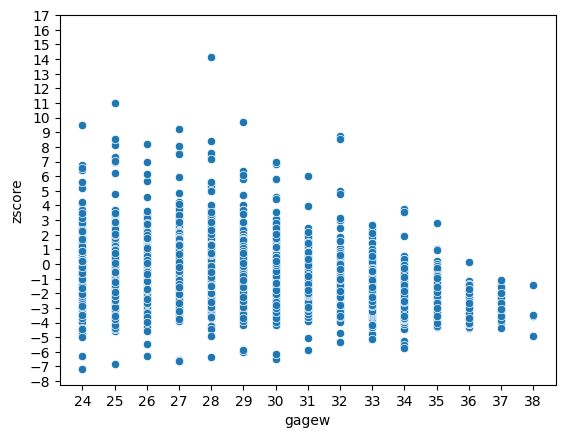

In [ ]:
# BMI Zscore 분포 그리기
print(bmi_data.shape)
sns.scatterplot(x = 'gagew', y = 'zscore', data = bmi_data)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(bmi_data['gagew'].min(), bmi_data['gagew'].max() + 1, 1))
plt.yticks(np.arange(int(bmi_data['zscore'].min() - 1), bmi_data['zscore'].max() + 3, 1))
plt.show()

(8218, 6)


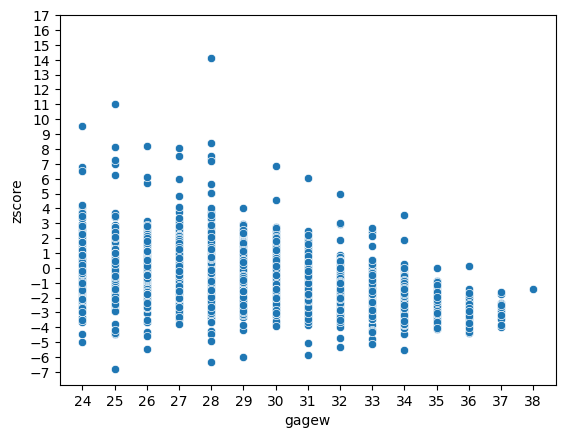

In [ ]:
# BMI Zscore 분포 그리기
print(bmi_data_m.shape)
sns.scatterplot(x = 'gagew', y = 'zscore', data = bmi_data_m)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(bmi_data_m['gagew'].min(), bmi_data_m['gagew'].max() + 1, 1))
plt.yticks(np.arange(int(bmi_data_m['zscore'].min() - 1), bmi_data_m['zscore'].max() + 3, 1))
plt.show()

(8252, 6)


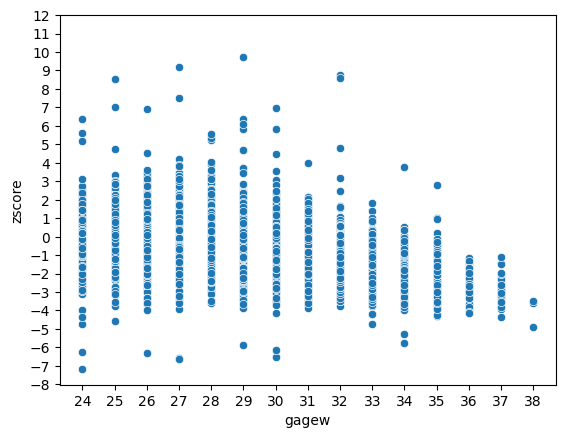

In [ ]:
# BMI Zscore 분포 그리기
print(bmi_data_f.shape)
sns.scatterplot(x = 'gagew', y = 'zscore', data = bmi_data_f)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(bmi_data_f['gagew'].min(), bmi_data_f['gagew'].max() + 1, 1))
plt.yticks(np.arange(int(bmi_data_f['zscore'].min() - 1), bmi_data_f['zscore'].max() + 3, 1))
plt.show()

In [ ]:
# 신뢰구간 내에 포함되는지 확인
mean_z = np.mean(bmi_data['zscore'])
std_z = np.mean(bmi_data['zscore'])

# 99.7% 신뢰구간(±3 표준편차) 계산
lower_bound = mean_z - 3 * std_z
upper_bound = mean_z + 3 * std_z

# 신뢰구간 내 포함 여부 확인
bmi_data["Within 99.7% CI"] = (bmi_data["zscore"] >= lower_bound) & (bmi_data["zscore"] <= upper_bound)

# 신뢰구간 내 포함된 데이터 비율 계산
within_997_CI_percentage = bmi_data["Within 99.7% CI"].mean() * 100

# 결과 출력
print(f"99.7% 신뢰구간: ({lower_bound:.2f}, {upper_bound:.2f})")
print(f"신뢰구간 내 포함된 데이터 비율: {within_997_CI_percentage:.2f}%")
print(bmi_data)

99.7% 신뢰구간: (0.64, -1.28)
신뢰구간 내 포함된 데이터 비율: 0.00%
       bwei  bhei  gagew  sex_sys_val        bmi    zscore  Within 99.7% CI
0      1350  39.0     30            1   8.875740 -0.028606            False
1       790  34.3     26            1   6.714889 -1.032871            False
2      1400  39.0     29            1   9.204471  0.731970            False
3      1340  36.0     29            1  10.339506  1.802777            False
4      1240  42.0     27            1   7.029478 -0.976796            False
...     ...   ...    ...          ...        ...       ...              ...
18121  1120  35.3     29            2   8.988115  0.741886            False
18122   800  33.0     26            2   7.346189  0.085329            False
18123  1450  39.0     31            2   9.533202  0.351899            False
18124   970  36.5     29            2   7.280916 -1.099888            False
18126  1480  41.0     28            1   8.804283  0.728573            False

[16470 rows x 7 columns]


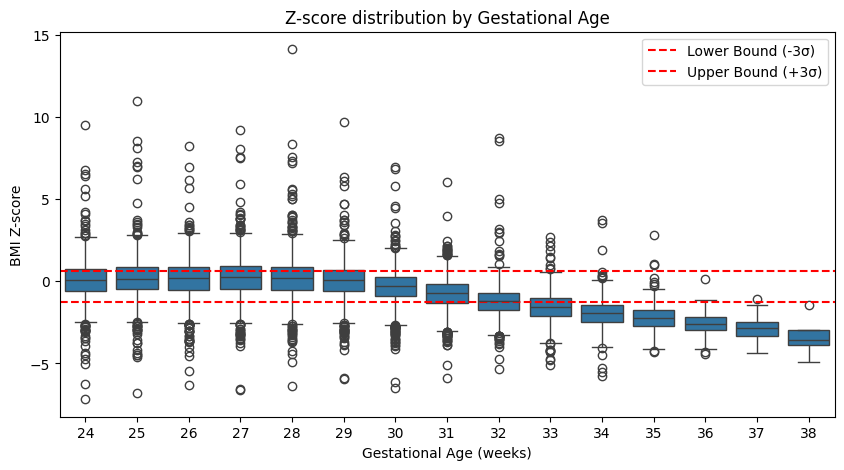

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=bmi_data["gagew"], y=bmi_data["zscore"])
plt.axhline(lower_bound, color='red', linestyle='dashed', label='Lower Bound (-3σ)')
plt.axhline(upper_bound, color='red', linestyle='dashed', label='Upper Bound (+3σ)')
plt.title("Z-score distribution by Gestational Age")
plt.xlabel("Gestational Age (weeks)")
plt.ylabel("BMI Z-score")
plt.legend()
plt.show()

### 퇴원시 BMI

<Axes: >

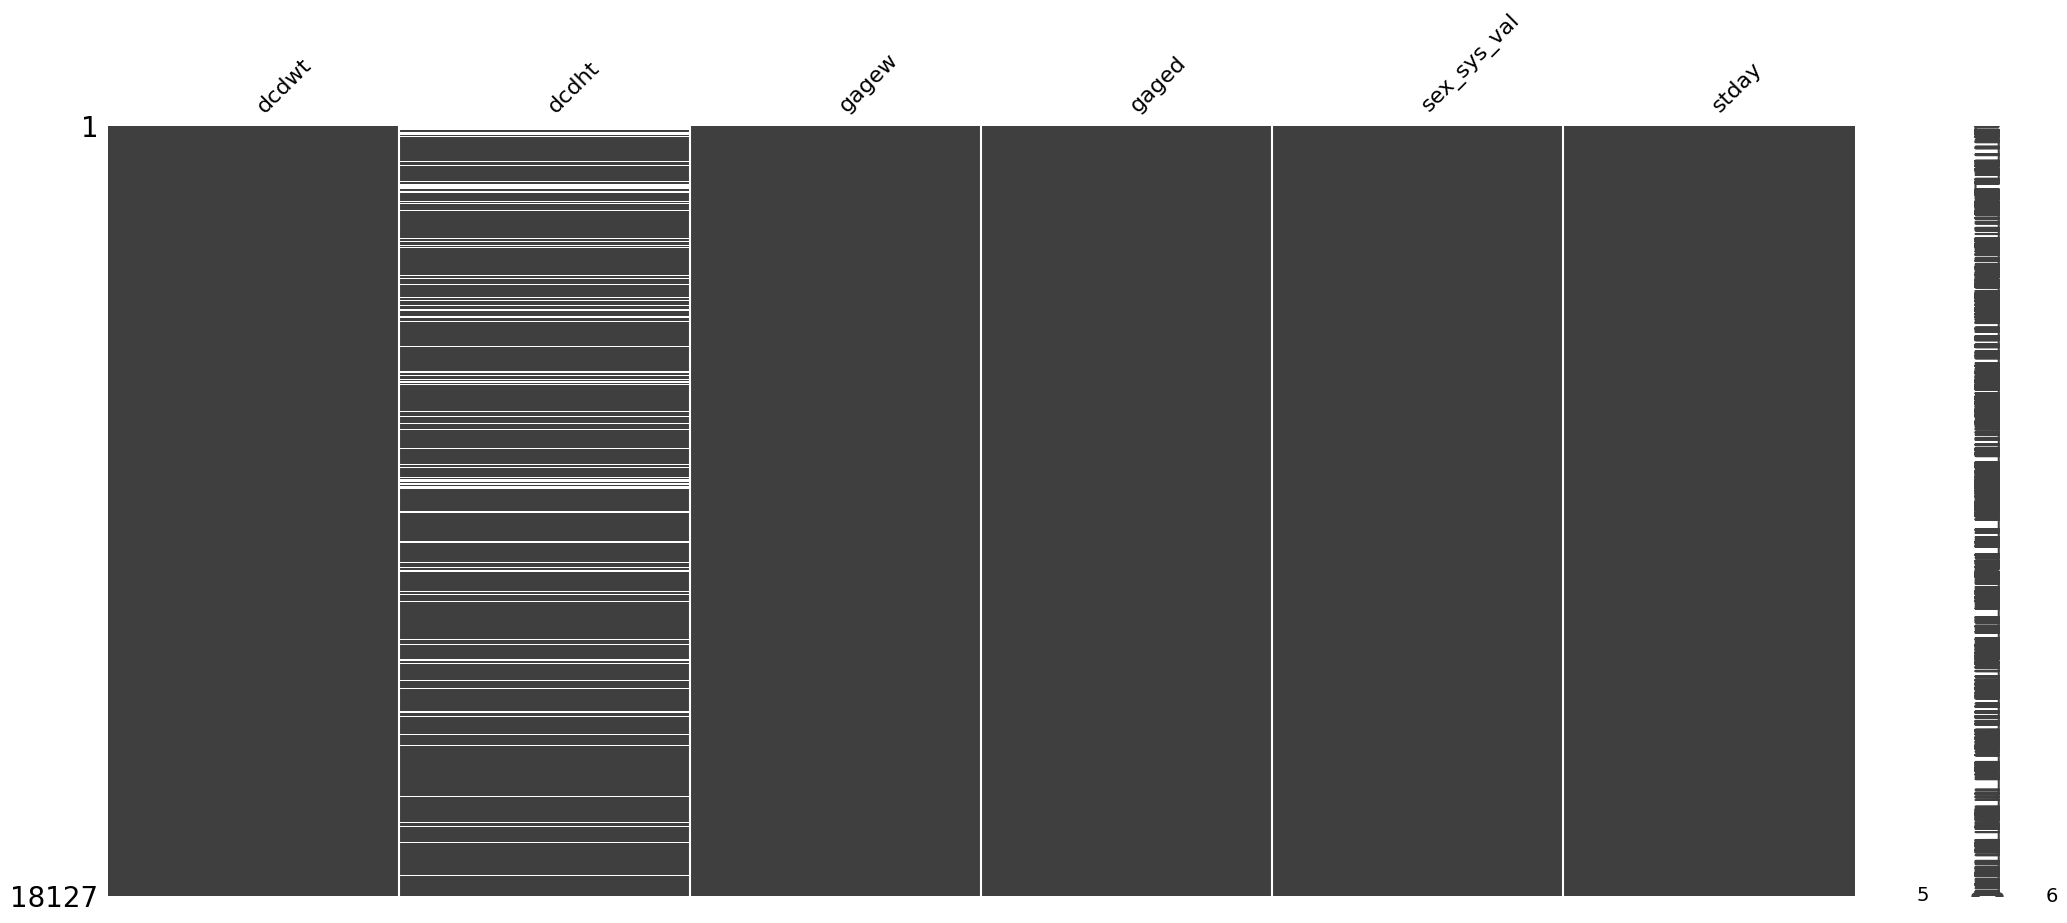

In [ ]:
import missingno as msno
discharge_bmi_data = data[['dcdwt', 'dcdht', 'gagew', 'gaged', 'sex_sys_val', 'stday']]

msno.matrix(discharge_bmi_data)

In [ ]:
# 재태 연령으로 구한 퇴원시 BMI
discharge_bmi_data = data[['dcdwt', 'dcdht', 'gagew', 'gaged', 'sex_sys_val', 'stday']] # stday : 재원일수
print(discharge_bmi_data.shape) # (18127, 6)
print(discharge_bmi_data.isnull().sum())
print(discharge_bmi_data.dropna())

# discharge_bmi_data['bmi'] = (discharge_bmi_data['dcdwt'] / discharge_bmi_data['dcdht']**2) * 10
discharge_bmi_data[["bmi", "zscore"]] = discharge_bmi_data.apply(
    lambda row: pd.Series(
        bmi_zscore(row["dcdwt"], row["dcdht"], row["gagew"], row["sex_sys_val"])
    ), 
    axis=1
)
discharge_bmi_data = discharge_bmi_data.dropna(axis = 0)

print(discharge_bmi_data.shape) # (16119, 6)
print(discharge_bmi_data.isnull().sum())
print(discharge_bmi_data['gagew'].value_counts()) # 모든 데이터가 24 ~ 41주 사이에 분포

discharge_bmi_data_m = discharge_bmi_data[discharge_bmi_data['sex_sys_val'] == 1]
discharge_bmi_data_f = discharge_bmi_data[discharge_bmi_data['sex_sys_val'] == 2]

print(discharge_bmi_data_m.shape)
print(discharge_bmi_data_f.shape)

(18127, 6)
dcdwt             0
dcdht          2008
gagew             0
gaged             0
sex_sys_val       0
stday             0
dtype: int64
       dcdwt  dcdht  gagew  gaged  sex_sys_val  stday
10      2580   47.5     28      3            2     89
87      2120   44.0     33      6            2     32
88      2240   47.0     30      1            2     56
89      1120   44.0     30      1            2     77
90      1940   41.0     26      1            2     70
...      ...    ...    ...    ...          ...    ...
18122   2720   47.0     26      5            2     84
18123   2260   44.0     31      3            2     40
18124   2420   46.5     29      4            2     69
18125    540   29.0     22      6            2      9
18126   3110   49.0     28      5            1     75

[16119 rows x 6 columns]
(15514, 8)
dcdwt          0
dcdht          0
gagew          0
gaged          0
sex_sys_val    0
stday          0
bmi            0
zscore         0
dtype: int64
gagew
29    2263
28   

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56096\4229137554.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  discharge_bmi_data[["bmi", "zscore"]] = discharge_bmi_data.apply(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56096\4229137554.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  discharge_bmi_data[["bmi", "zscore"]] = discharge_bmi_data.apply(


(7697, 8)


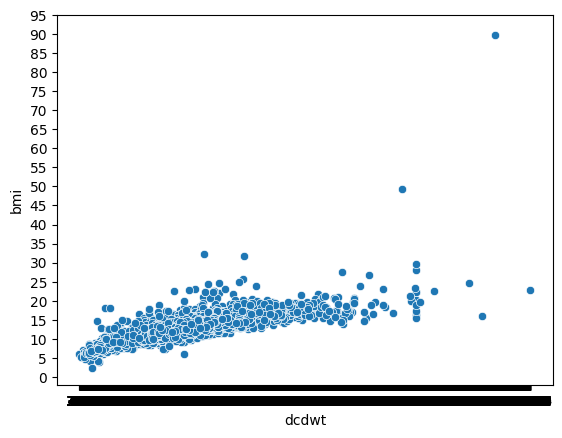

In [ ]:
# 체중 분포 그리기 - 남성
print(discharge_bmi_data_m.shape)
sns.scatterplot(x = 'dcdwt', y = 'bmi', data = discharge_bmi_data_m)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(discharge_bmi_data_m['dcdwt'].min(), discharge_bmi_data_m['dcdwt'].max() + 1, 1))
plt.yticks(np.arange(0, discharge_bmi_data_m['bmi'].max() + 6, 5))
plt.show()

In [ ]:
# 신장 분포 그리기 - 남성
print(discharge_bmi_data_m.shape)
sns.scatterplot(x = 'dcdwt', y = 'bmi', data = discharge_bmi_data_m)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(discharge_bmi_data_m['dcdwt'].min(), discharge_bmi_data_m['dcdwt'].max() + 1, 1))
plt.yticks(np.arange(0, discharge_bmi_data_m['bmi'].max() + 6, 5))
plt.show()

In [ ]:
discharge_bmi_data.loc[(-1 <= discharge_bmi_data['zscore']) & (discharge_bmi_data['zscore'] <= 1), 'label'] = 1
discharge_bmi_data.loc[discharge_bmi_data['zscore'] > 1, 'label'] = 2
discharge_bmi_data.loc[discharge_bmi_data['zscore'] < -1, 'label'] = 3

discharge_bmi_data['label'].value_counts()

label
2.0    13342
1.0     1861
3.0      311
Name: count, dtype: int64

In [ ]:
discharge_bmi_data.loc[(-2 <= discharge_bmi_data['zscore']) & (discharge_bmi_data['zscore'] <= 2), 'label'] = 1
discharge_bmi_data.loc[discharge_bmi_data['zscore'] > 2, 'label'] = 2
discharge_bmi_data.loc[discharge_bmi_data['zscore'] < -2, 'label'] = 3

discharge_bmi_data['label'].value_counts()

label
2.0    11559
1.0     3883
3.0       72
Name: count, dtype: int64

(7697, 8)


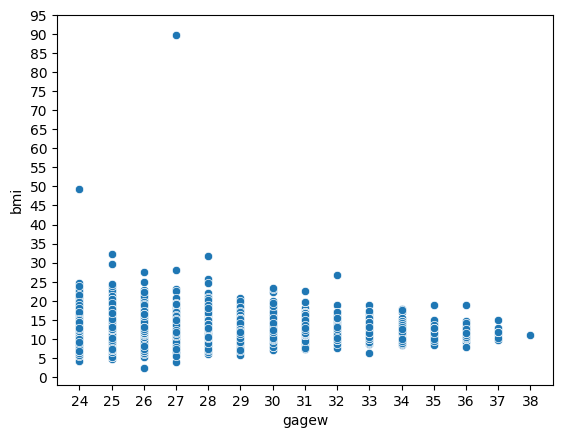

In [ ]:
# BMI 분포 그리기 - 남성
print(discharge_bmi_data_m.shape)
sns.scatterplot(x = 'gagew', y = 'bmi', data = discharge_bmi_data_m)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(discharge_bmi_data_m['gagew'].min(), discharge_bmi_data_m['gagew'].max() + 1, 1))
plt.yticks(np.arange(0, discharge_bmi_data_m['bmi'].max() + 6, 5))
plt.show()

(7817, 8)


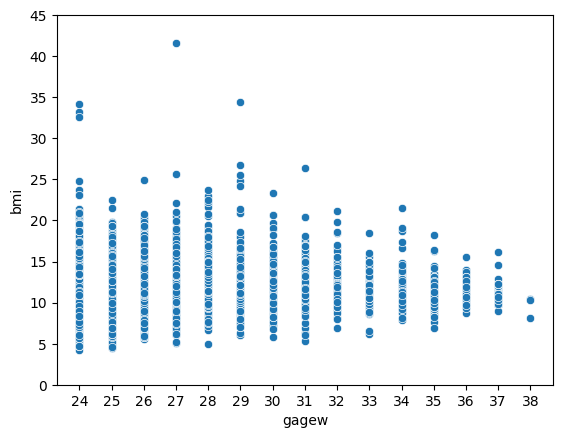

In [ ]:
# BMI 분포 그리기 - 여성
print(discharge_bmi_data_f.shape)
sns.scatterplot(x = 'gagew', y = 'bmi', data = discharge_bmi_data_f)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(discharge_bmi_data_f['gagew'].min(), discharge_bmi_data_f['gagew'].max() + 1, 1))
plt.yticks(np.arange(0, discharge_bmi_data_f['bmi'].max() + 6, 5))
plt.show()

(7817, 8)


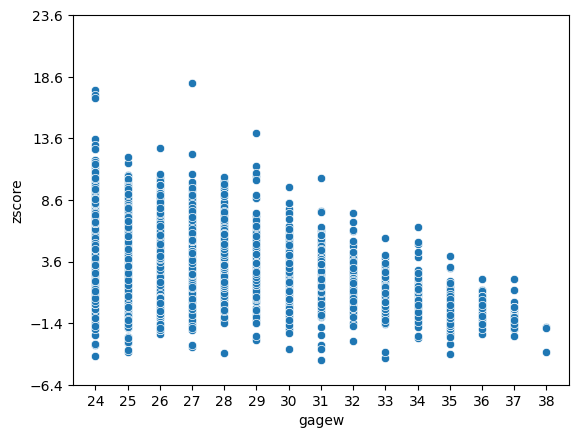

In [ ]:
# BMI Zscore 분포 그리기 - 여성
print(discharge_bmi_data_f.shape)
sns.scatterplot(x = 'gagew', y = 'zscore', data = discharge_bmi_data_f)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(discharge_bmi_data_f['gagew'].min(), discharge_bmi_data_f['gagew'].max() + 1, 1))
plt.yticks(np.arange(discharge_bmi_data_f['zscore'].min() - 2, discharge_bmi_data_f['zscore'].max() + 6, 5))
plt.show()

(7697, 8)


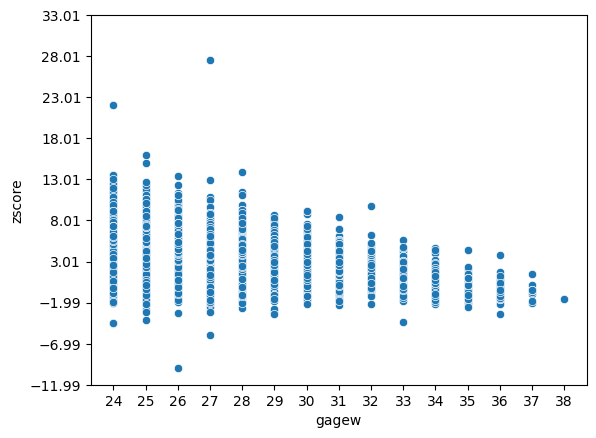

In [ ]:
# BMI Zscore 분포 그리기 - 남성
print(discharge_bmi_data_m.shape)
sns.scatterplot(x = 'gagew', y = 'zscore', data = discharge_bmi_data_m)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(discharge_bmi_data_m['gagew'].min(), discharge_bmi_data_m['gagew'].max() + 1, 1))
plt.yticks(np.arange(discharge_bmi_data_m['zscore'].min() - 2, discharge_bmi_data_m['zscore'].max() + 6, 5))
plt.show()

(7697, 8)


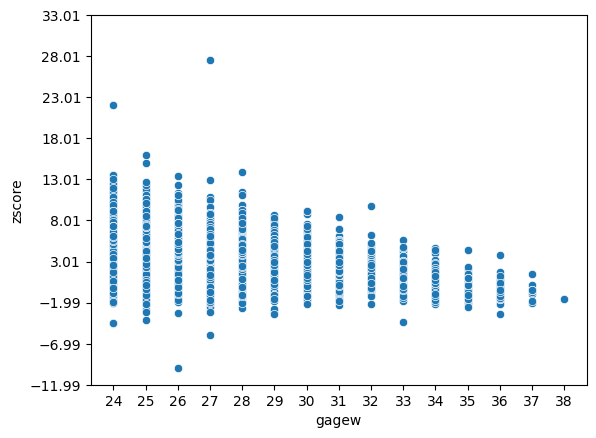

In [ ]:
discharge_bmi_data

print(discharge_bmi_data_m.shape)
sns.scatterplot(x = 'gagew', y = 'zscore', data = discharge_bmi_data_m)
# x축의 tick을 1씩 표시하도록 설정
plt.xticks(np.arange(discharge_bmi_data_m['gagew'].min(), discharge_bmi_data_m['gagew'].max() + 1, 1))
plt.yticks(np.arange(discharge_bmi_data_m['zscore'].min() - 2, discharge_bmi_data_m['zscore'].max() + 6, 5))
plt.show()

In [ ]:
print(discharge_bmi_data.head())
print(discharge_bmi_data.groupby('gagew')['zscore'].mean())
print(discharge_bmi_data.groupby('gagew')['zscore'].std())

    dcdwt  dcdht  gagew  gaged  sex_sys_val  stday        bmi    zscore
10   2580   47.5     28      3            2     89  11.434903  3.325606
87   2120   44.0     33      6            2     32  10.950413  0.641931
88   2240   47.0     30      1            2     56  10.140335  1.387772
89   1120   44.0     30      1            2     77   5.785124 -3.464014
90   1940   41.0     26      1            2     70  11.540750  4.364478
gagew
24    5.924407
25    5.656290
26    5.475011
27    4.874269
28    4.306100
29    3.640599
30    2.982055
31    2.276057
32    1.725530
33    1.081464
34    0.566933
35   -0.152045
36   -0.416924
37   -0.849429
38   -2.191809
Name: zscore, dtype: float64
gagew
24    3.470453
25    2.858877
26    2.268555
27    1.966652
28    1.582861
29    1.372961
30    1.273028
31    1.208035
32    1.140800
33    1.087465
34    1.034686
35    0.986799
36    0.971637
37    0.971149
38    1.027377
Name: zscore, dtype: float64


### 사망한 사람의 퇴원 BMI를 계산이 가능한지?

In [ ]:
death_data = data[data['death'].isna()]
death_data[["dcdht", "dcdwt"]].isnull().sum() # 1066

dcdht    1066
dcdwt       0
dtype: int64

In [ ]:
tmp = data[data['dcdht'].notna()]
tmp[["death", "dcdht", "dcdwt"]].notna().sum() 

death     1463
dcdht    16119
dcdwt    16119
dtype: int64

In [ ]:
tmp = data[data['death'].notna()]
tmp[["death", "dcdht", "dcdwt"]].isna().sum() 

death      0
dcdht    942
dcdwt      0
dtype: int64

In [ ]:
tmp[(tmp['death'].notna()) & (tmp['dcdht'].notna())]

,subjnm,sex_sys_val,birthdt,sex,subjno,mulg,bir1,bir2,bir3,bir4,...,troj,trojetc,death,car,neu,inf,gas,con,oth,tbrfeed
175,ㄱㅎㄴ,2,2013-08-31,NaN,008-00018,1,NaN,NaN,NaN,NaN,...,NaN,NaN,3.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN
222,ㅂㅎㅈ,1,2013-11-26,NaN,021-00018,1,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN
223,ㄱㅁㅅ,1,2013-11-22,NaN,021-00019,1,NaN,NaN,NaN,NaN,...,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN
224,ㅊㅇㅈ,2,2013-11-24,NaN,021-00020,1,NaN,NaN,NaN,NaN,...,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN
307,ㅊㅇㄴ,1,2013-01-02,NaN,023-00032,1,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18060,ㅈㅇ,1,2021-02-09,1.0,045-00223,2,1.0,NaN,NaN,NaN,...,NaN,NaN,2.0,NaN,2.0,NaN,NaN,NaN,NaN,3.0
18086,ㄸㄹㅅㄴ,2,2021-04-13,2.0,106-00061,1,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0
18090,ㅎㅇㅅㄹ,2,2021-10-03,2.0,106-00065,1,NaN,NaN,NaN,NaN,...,NaN,NaN,4.0,NaN,NaN,NaN,1.0,NaN,NaN,1.0
18106,ㅈㄴㅇ,2,2021-04-13,2.0,007-00302,1,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,5.0,NaN,NaN,NaN,NaN,NaN,1.0


## KNN-BMI데이터 보기

In [ ]:
# 설정 파일 및 데이터 불러오기
result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_bmi.csv"
data = pd.read_csv(os.path.join(result_path, data_file))
data.shape

(18127, 91)

사망한 사람 제외

In [ ]:
data = data[data['death'].isna()]
data.shape

(15722, 91)

성별을 모르는 사람 제외

In [ ]:
data = data[data['sex_sys_val'] != 3]
data.shape

(15717, 91)

퇴원시 신장 및 체중이 없는 사람 제외

In [ ]:
data = data.dropna(subset=["dcdht", "dcdwt"])
data.shape

(14651, 91)

퇴원시 신장 없는 사람 확인

count    14651.000000
mean        28.910245
std          2.857778
min         22.000000
25%         27.000000
50%         29.000000
75%         31.000000
max         38.000000
Name: gagew, dtype: float64
count    14651.000000
mean        72.944782
std         40.036826
min         10.000000
25%         46.000000
50%         64.000000
75%         90.000000
max        399.000000
Name: stday, dtype: float64


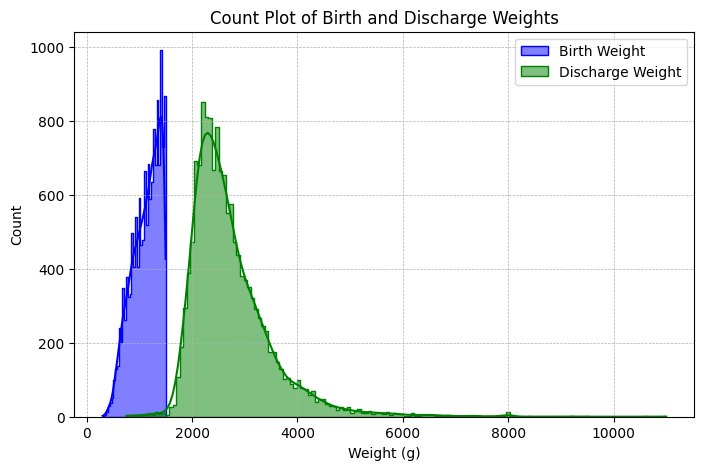

In [ ]:

# 재태주수 요약
print(data['gagew'].describe())
# 입원 기간 요약
print(data['stday'].describe())

plt.figure(figsize=(8, 5))

# Histplot with KDE (Birth Weight)
sns.histplot(x=data["bwei"], label="Birth Weight", color="blue", alpha=0.5,
             kde=True, stat="count", element="step", common_norm=False)

# Histplot with KDE (Discharge Weight)
sns.histplot(x=data["dcdwt"], label="Discharge Weight", color="green", alpha=0.5,
             kde=True, stat="count", element="step", common_norm=False)

# 그래프 설정
plt.xlabel("Weight (g)")
plt.ylabel("Count")
plt.title("Count Plot of Birth and Discharge Weights")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()


In [ ]:
data["prom_duration"].describe()

count    13556.000000
mean         2.465034
std          8.657832
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        156.000000
Name: prom_duration, dtype: float64

In [ ]:
data["promd"].describe()

count           3969
unique          2175
top       2020-05-03
freq               9
Name: promd, dtype: object

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_67552\2895961606.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


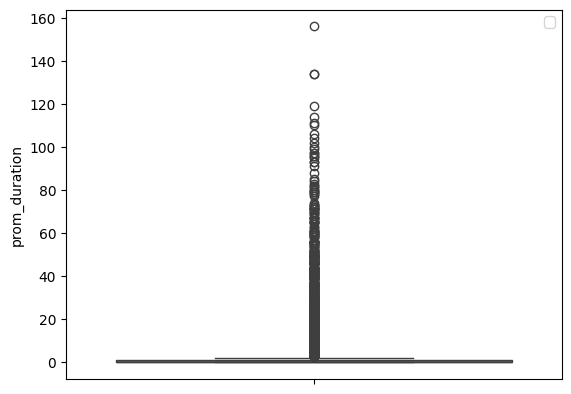

In [ ]:
sns.boxplot(data["prom_duration"])
# plt.axhline(lower_bound, color='red', linestyle='dashed', label='Lower Bound (-3σ)')
# plt.axhline(upper_bound, color='red', linestyle='dashed', label='Upper Bound (+3σ)')
# plt.title("Z-score distribution by Gestational Age")
# plt.xlabel("Gestational Age (weeks)")
# plt.ylabel("BMI Z-score")
plt.legend()
plt.show()

In [ ]:
data["stday"].describe()

count    14651.000000
mean        72.944782
std         40.036826
min         10.000000
25%         46.000000
50%         64.000000
75%         90.000000
max        399.000000
Name: stday, dtype: float64

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_67552\344556667.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


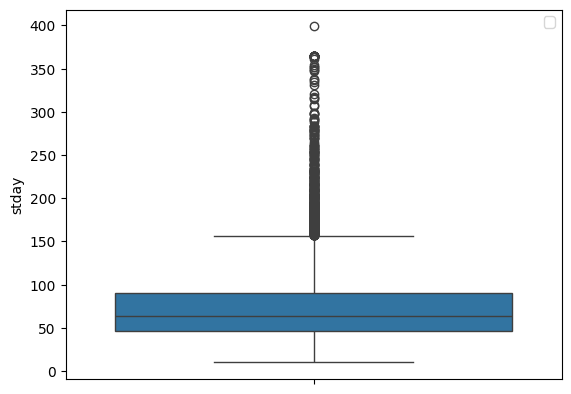

In [ ]:
sns.boxplot(data["stday"])
# plt.axhline(lower_bound, color='red', linestyle='dashed', label='Lower Bound (-3σ)')
# plt.axhline(upper_bound, color='red', linestyle='dashed', label='Upper Bound (+3σ)')
# plt.title("Z-score distribution by Gestational Age")
# plt.xlabel("Gestational Age (weeks)")
# plt.ylabel("BMI Z-score")
plt.legend()
plt.show()

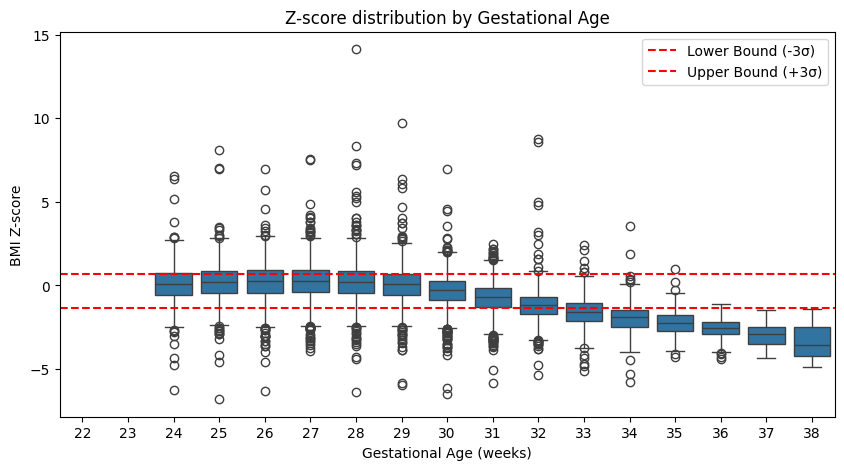

In [ ]:
# 신뢰구간 내에 포함되는지 확인
mean_z = np.mean(data['birth_bmi_zscore'])
std_z = np.mean(data['birth_bmi_zscore'])

# 99.7% 신뢰구간(±3 표준편차) 계산
lower_bound = mean_z - 3 * std_z
upper_bound = mean_z + 3 * std_z

plt.figure(figsize=(10, 5))
sns.boxplot(x=data["gagew"], y=data["birth_bmi_zscore"])
plt.axhline(lower_bound, color='red', linestyle='dashed', label='Lower Bound (-3σ)')
plt.axhline(upper_bound, color='red', linestyle='dashed', label='Upper Bound (+3σ)')
plt.title("Z-score distribution by Gestational Age")
plt.xlabel("Gestational Age (weeks)")
plt.ylabel("BMI Z-score")
plt.legend()
plt.show()

In [ ]:
# 설정 파일 및 데이터 불러오기
result_path = "F:/data/knn/" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_dataset.csv"
data = pd.read_csv(os.path.join(result_path, data_file))

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_67552\2985538052.py:4: DtypeWarning: Columns (22,90,102,110,111,117,132,139,162,201,205,215,217) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(result_path, data_file))


In [ ]:
data["birth_age"] = (pd.to_datetime(data["fdcdt"])- pd.to_datetime(data["birthdt"])).dt.days // 30
data["birth_age"].value_counts()


birth_age
1     6299
2     4913
0     2793
3     2381
4     1014
5      363
6      158
7       80
8       44
9       37
12      23
11      12
10       9
13       1
Name: count, dtype: int64

In [ ]:
# DCDWT  단위: g
# DCDHT  단위: cm
data = data.dropna(subset=["dcdht", "dcdwt"])
print(data.columns)
data["dcd_bmi"] = (data["dcdwt"]*0.001)/(data["dcdht"]*0.01)**2
data["dcd_bmi"]

Index(['subjnm', 'sex_sys_val', 'birthdt', 'sex', 'subjno', 'mulg', 'bir1',
       'bir2', 'bir3', 'bir4',
       ...
       'trojetc', 'death', 'car', 'neu', 'inf', 'gas', 'con', 'oth', 'tbrfeed',
       'birth_age'],
      dtype='object', length=229)


10       11.434903
87       10.950413
88       10.140335
89        5.785124
90       11.540750
           ...    
18122    12.313264
18123    11.673554
18124    11.192045
18125     6.420927
18126    12.952936
Name: dcd_bmi, Length: 16119, dtype: float64

In [ ]:
data.groupby(["birth_age", "sex_sys_val"])["dcd_bmi"].describe()

count       mean       std        min        25%  \
birth_age sex_sys_val                                                      
0         1             972.0   9.264500  3.413056   2.305878   7.294918   
          2             992.0   9.323363  2.212865   2.077562   7.444444   
          3               2.0   9.074324  1.902725   7.728894   8.401609   
1         1            2763.0  11.959781  1.413077   4.591368  11.061728   
          2            3038.0  11.780619  1.359557   6.004420  10.962963   
          3               1.0  12.022569       NaN  12.022569  12.022569   
2         1            2247.0  13.115972  1.722610   6.004420  11.996378   
          2            2270.0  12.810397  1.757909   5.382545  11.737024   
          3               2.0  13.538472  1.723180  12.320000  12.929236   
3         1            1165.0  14.114658  2.044870   7.541322  12.848690   
          2            1038.0  13.815974  2.223998   8.638889  12.540559   
          3               1.0  16.167355       NaN  16.167355  16.167355   
4         1             490.0  14.885536  2.166940   7.238520  13.462113   
          2             460.0  14.657958  2.205307   7.352941  13.241435   
5         1             188.0  15.673469  2.049882   8.143653  14.344884   
          2             151.0  15.307207  2.457590   4.998078  13.962249   
6         1              80.0  16.483049  2.750558  11.284542  14.792627   
          2              69.0  16.587145  2.807442  12.174211  15.058084   
7         1              42.0  18.241439  5.798200  11.801301  16.092082   
          2              34.0  16.439691  2.986310  11.760000  13.785675   
8         1              25.0  18.910022  3.900259  12.302960  16.514178   
          2              17.0  16.950308  3.187702  12.459950  14.284555   
9         1              13.0  16.884507  2.867450  13.365707  15.053254   
          2              18.0  16.315140  2.206758  12.313600  14.804905   
10        1               4.0  18.345941  3.626344  15.432099  15.436537   
          2               3.0  14.858234  2.356960  12.781065  13.577481   
11        1               4.0  18.883091  4.155108  15.546385  16.131494   
          2               7.0  16.774385  2.316751  14.461428  14.508517   
12        1               7.0  16.846076  1.711980  14.462810  15.946403   
          2              15.0  18.872428  2.417704  15.363512  17.201569   
13        1               1.0  10.383991       NaN  10.383991  10.383991   

                             50%        75%        max  
birth_age sex_sys_val                                   
0         1             9.356567  10.916503  89.898990  
          2             9.825006  10.947002  21.508040  
          3             9.074324   9.747038  10.419753  
1         1            11.867936  12.780150  20.812500  
          2            11.703704  12.500000  23.045695  
          3            12.022569  12.022569  12.022569  
2         1            13.000396  14.074074  24.584488  
          2            12.624669  13.714600  26.364234  
          3            13.538472  14.147708  14.756944  
3         1            13.894140  15.091933  32.350718  
          2            13.623186  14.756688  41.587902  
          3            16.167355  16.167355  16.167355  
4         1            14.769604  16.081916  22.937500  
          2            14.561593  15.872645  34.127868  
5         1            15.670031  17.267225  21.146315  
          2            15.150240  16.852961  26.782025  
6         1            16.176012  17.993047  27.950039  
          2            16.259695  17.538265  32.552280  
7         1            16.960580  19.652742  49.222881  
          2            16.333766  18.267637  23.703704  
8         1            18.239230  20.396694  29.585799  
          2            16.375934  19.322235  24.778107  
9         1            15.820800  17.099623  23.317993  
          2            16.162723  17.908436  20.793388  
10        1            17.513895 

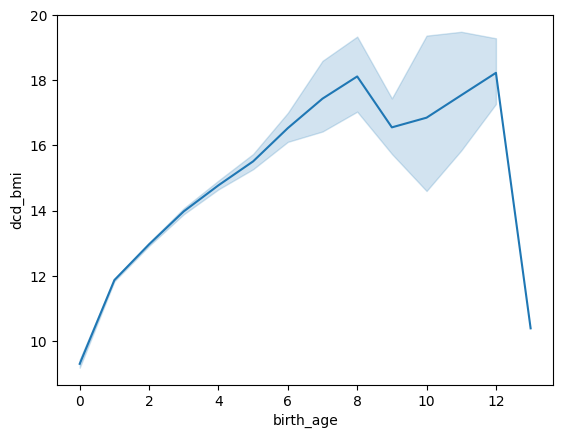

In [ ]:
sns.lineplot(x = data["birth_age"], y = data["dcd_bmi"])
plt.show()

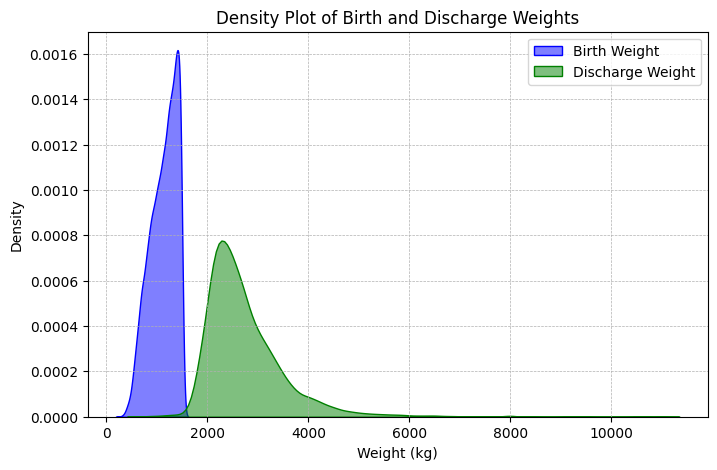

In [ ]:
plt.figure(figsize=(8, 5))

# KDE 그래프 (Birth Weight)
sns.kdeplot(x=data["bwei"], label="Birth Weight", fill=True, color="blue", alpha=0.5,
            weights=np.ones(len(data["bwei"])) * len(data["bwei"]))

# KDE 그래프 (Discharge Weight)
sns.kdeplot(x=data["dcdwt"], label="Discharge Weight", fill=True, color="green", alpha=0.5,
            weights=np.ones(len(data["dcdwt"])) * len(data["dcdwt"]))

# 그래프 설정
plt.xlabel("Weight (kg)")
plt.ylabel("Density")
plt.title("Density Plot of Birth and Discharge Weights")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()


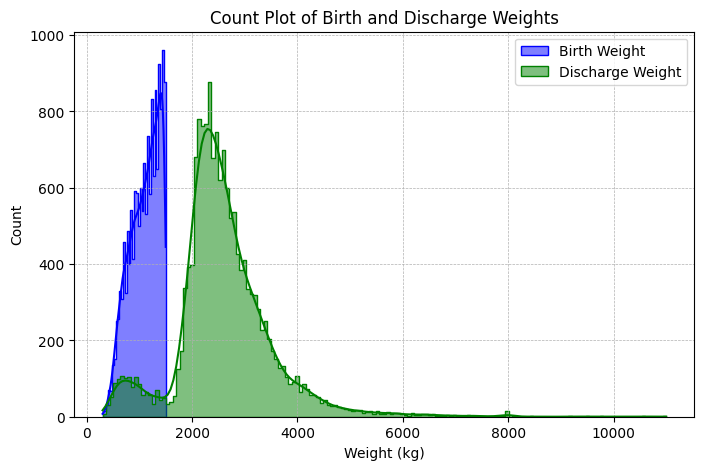

In [ ]:
plt.figure(figsize=(8, 5))

# Histplot with KDE (Birth Weight)
sns.histplot(x=data["bwei"], label="Birth Weight", color="blue", alpha=0.5,
             kde=True, stat="count", element="step", common_norm=False)

# Histplot with KDE (Discharge Weight)
sns.histplot(x=data["dcdwt"], label="Discharge Weight", color="green", alpha=0.5,
             kde=True, stat="count", element="step", common_norm=False)

# 그래프 설정
plt.xlabel("Weight (kg)")
plt.ylabel("Count")
plt.title("Count Plot of Birth and Discharge Weights")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

In [ ]:
data[["bwei", "bhei", "dcdwt", "dcdht", "stday"]]

,bwei,bhei,dcdwt,dcdht,stday
10,990,34.0,2580,47.5,89
87,1380,41.0,2120,44.0,32
88,980,40.0,2240,47.0,56
89,1060,36.0,1120,44.0,77
90,960,36.0,1940,41.0,70
...,...,...,...,...,...
18122,800,33.0,2720,47.0,84
18123,1450,39.0,2260,44.0,40
18124,970,36.5,2420,46.5,69
18125,530,28.5,540,29.0,9


### 새로운 BMI Z-score 계산

퇴원시기의 교정 주수 분포 확인

(14651, 91)
       corrected_age      dcd_aged      dcd_agem    age_months
count   14651.000000  14651.000000  14651.000000  14651.000000
mean       39.331035     73.147362      1.904443      1.049212
std         4.390297     40.176985      1.349307      1.708472
min        28.000000     10.000000      0.000000      0.000000
25%        37.000000     46.000000      1.000000      0.000000
50%        38.000000     64.000000      2.000000      0.000000
75%        40.000000     90.000000      2.000000      2.000000
max        89.000000    399.000000     13.000000     13.000000


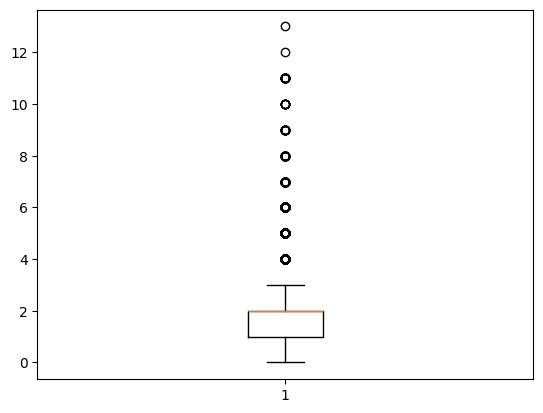

In [ ]:
# 올바른 데이터 불러왔는지 확인
print(data.shape)

# 교정 주수 계산
tmp = data.copy()
tmp["corrected_age"] = (tmp["gagew"] * 7 + tmp["gaged"] + tmp["stday"] ) // 7 # 교정주수
tmp["dcd_aged"] = (pd.to_datetime(data["fdcdt"])- pd.to_datetime(data["birthdt"])).dt.days 
tmp["dcd_agem"] = tmp["dcd_aged"] // 30.4375

# 퇴원 시기 교정 주수가 40주 미만이라면 0개월을(Birth) 기준으로
# 퇴원 시기 교정 주수가 40주 이상이라면 (퇴원일 - 출생일) / 30.4375로 나이 계산
tmp["age_months"] = np.where(tmp["corrected_age"] < 40, 0, tmp["dcd_agem"])
print(tmp[["corrected_age", "dcd_aged", "dcd_agem", "age_months"]].describe())


plt.boxplot(tmp["dcd_agem"])
plt.show()

In [ ]:
print(tmp.shape)

(14651, 95)


In [ ]:
# 설정 파일 및 데이터 불러오기
result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_bmi.csv"
data = pd.read_csv(os.path.join(result_path, data_file))

tmp = data.copy()

tmp["dcd_bmi_zscore"].describe()
# tmp["dcd_bmi_zscore"]

count    14651.000000
mean        -1.351428
std          1.485051
min        -14.079186
25%         -2.289473
50%         -1.360457
75%         -0.423483
max         11.293714
Name: dcd_bmi_zscore, dtype: float64

In [ ]:
tmp["label"].value_counts()

label
3.0    8856
1.0    5088
2.0     707
Name: count, dtype: int64

In [ ]:
tmp.groupby("age_months")["dcd_bmi"].describe()

,count,mean,std,min,25%,50%,75%,max
age_months,,,,,,,,
0.0,9681.0,12.189611,1.552054,6.004420,11.162638,12.049383,13.062500,32.350718
1.0,482.0,11.974525,1.404382,8.440000,11.006997,11.830630,12.706267,18.858131
2.0,1280.0,13.236674,1.891307,5.382545,11.970774,13.077884,14.214404,25.528007
3.0,1750.0,14.102035,2.128068,8.638889,12.870407,13.891514,15.070296,41.587902
4.0,867.0,14.783615,2.164078,7.238520,13.382534,14.685644,15.995852,34.127868
5.0,312.0,15.686860,2.472115,4.998078,14.279531,15.441964,17.222049,32.552280
6.0,124.0,16.216086,2.072597,11.284542,14.788386,16.249192,17.578125,20.527778
7.0,59.0,17.587170,5.139554,11.760000,14.626955,16.962483,18.837169,49.222881
8.0,37.0,17.062982,3.321286,12.302960,14.849108,16.514178,18.115702,29.585799


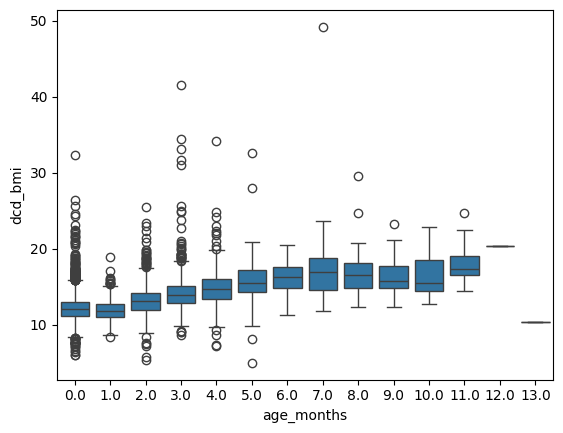

In [ ]:
sns.boxplot(x = "age_months", y = "dcd_bmi", data = tmp)
plt.show()

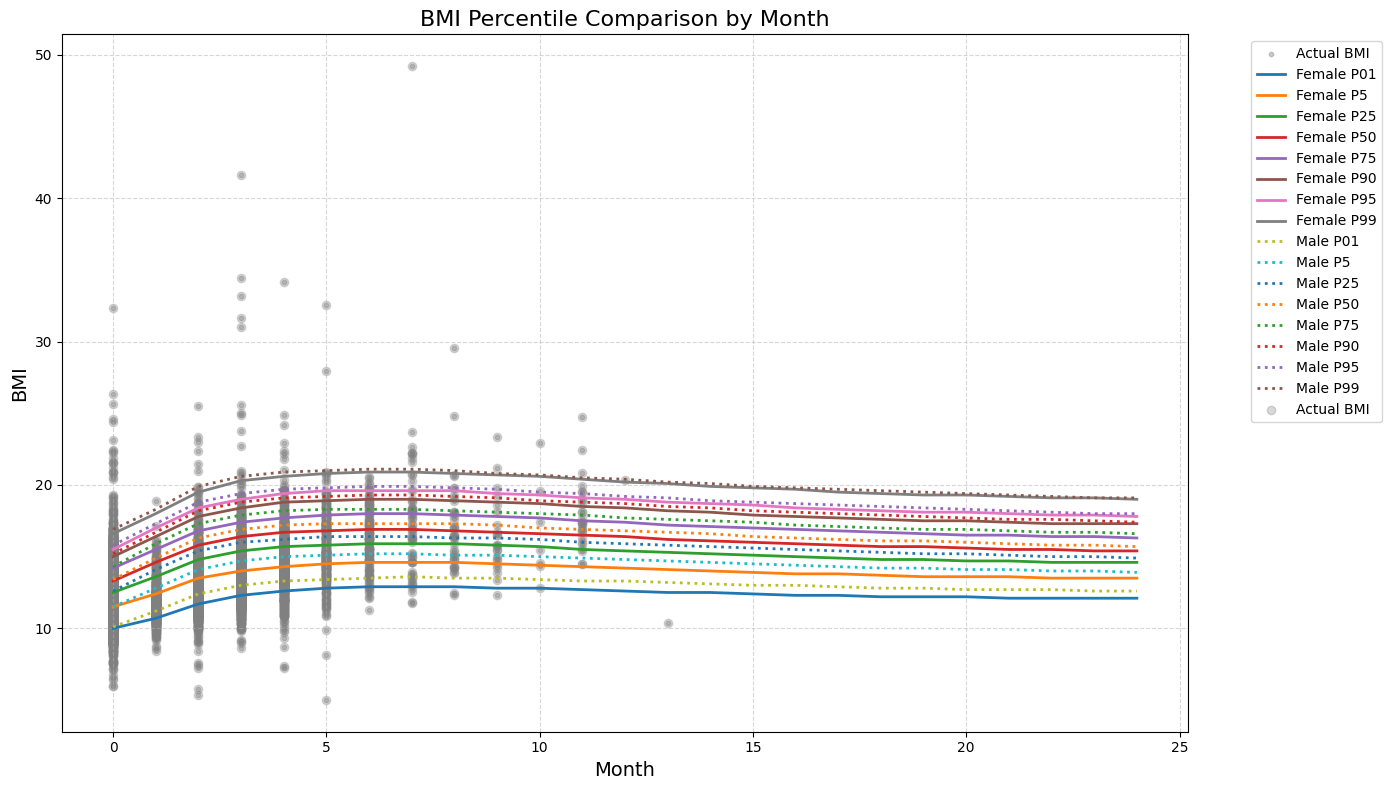

In [ ]:
# 교정주수가 40주 미만일 경우
def plot_bmi_distribution(df_bmi, df_female, df_male):
    plt.figure(figsize=(14, 8))

    # 실제 BMI 데이터
    # plt.plot(df_bmi['age_months'], df_bmi['dcd_bmi'], 'o-', label='Actual BMI', linewidth=2, markersize=5)
    plt.scatter(df_bmi['age_months'], df_bmi['dcd_bmi'], color='grey', alpha=0.4, label='Actual BMI', s=10)

    # percentile 열들 지정 (주요 percentile만 선택하여 시각화)
    percentiles = ['P01', 'P5', 'P25', 'P50', 'P75', 'P90', 'P95', 'P99']

    # 여성 percentile 라인
    for perc in percentiles:
        plt.plot(df_female['Month'], df_female[perc], linestyle='-', linewidth=2, label=f'Female {perc}')

    # 남성 percentile 라인
    for perc in percentiles:
        plt.plot(df_male['Month'], df_male[perc], linestyle=':', linewidth=2, label=f'Male {perc}')

    plt.scatter(df_bmi['age_months'], df_bmi['dcd_bmi'], alpha=0.3, color='gray', label='Actual BMI')

    plt.xlabel('Month', fontsize=14)
    plt.ylabel('BMI', fontsize=14)
    plt.title('BMI Percentile Comparison by Month', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_bmi.csv"
df_bmi = pd.read_csv(os.path.join(result_path, data_file))
df_male = pd.read_excel("tab_bmi_boys_p_0_2.xlsx")
df_female = pd.read_excel("tab_bmi_girls_p_0_2.xlsx")

# 함수 호출 예시
plot_bmi_distribution(df_bmi, df_female, df_male)

성별별 data shape:: (7228, 96) (7423, 96)


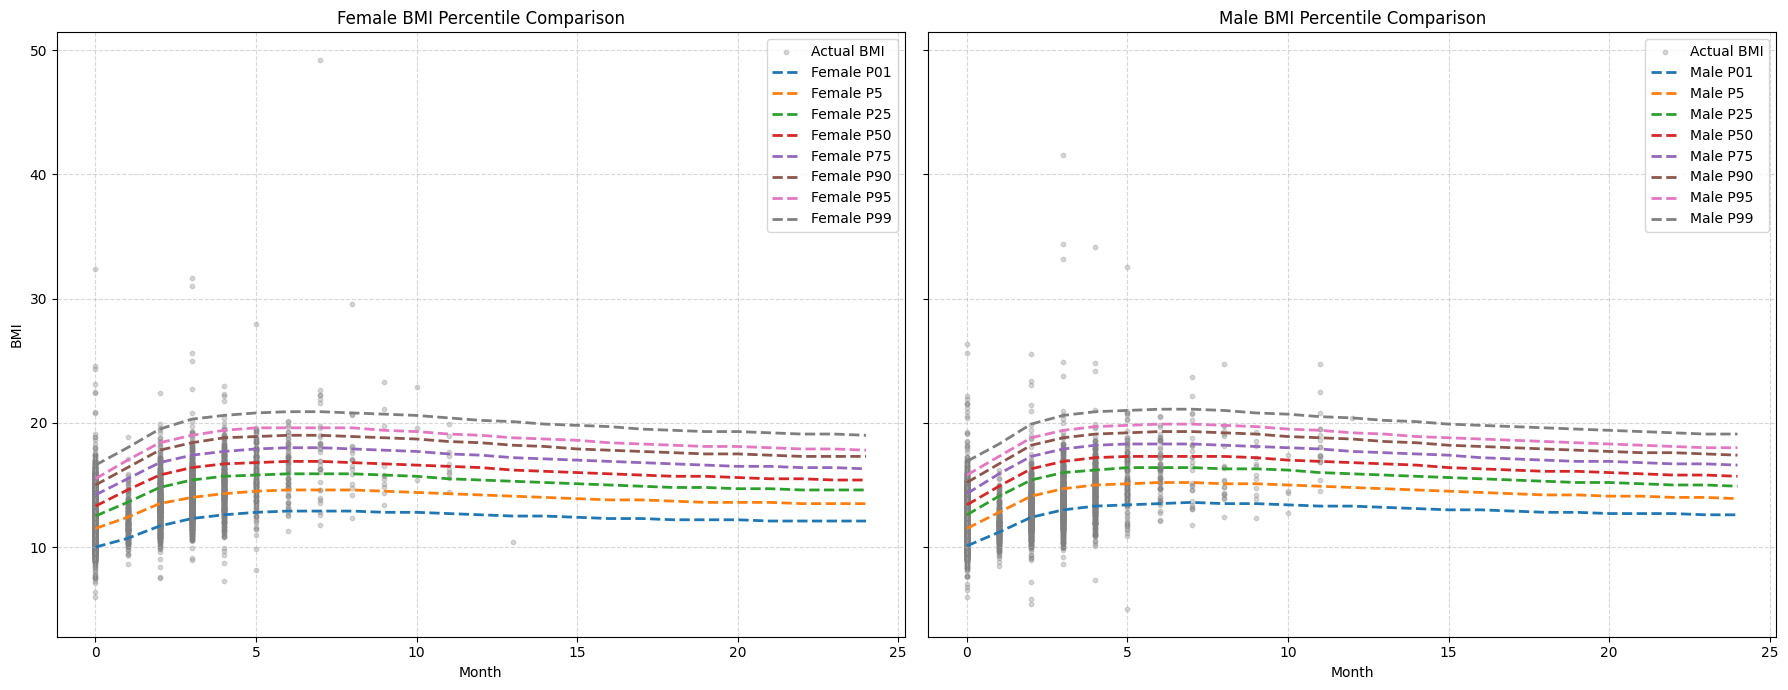

In [ ]:
def plot_bmi_distribution(df_bmi, df_female, df_male):
    percentiles = ['P01', 'P5', 'P25', 'P50', 'P75', 'P90', 'P95', 'P99']

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    df_bmi_male = df_bmi[df_bmi["sex_sys_val"] == 1]
    df_bmi_female = df_bmi[df_bmi["sex_sys_val"] == 2]
    print('성별별 data shape::', df_bmi_male.shape, df_bmi_female.shape)
    
    # 여성 BMI Percentile
    axes[0].scatter(df_bmi_male['age_months'], df_bmi_male['dcd_bmi'], color='gray', alpha=0.3, label='Actual BMI', s=10)
    for perc in percentiles:
        axes[0].plot(df_female['Month'], df_female[perc], linestyle='--', linewidth=2, label=f'Female {perc}')
    axes[0].set_title('Female BMI Percentile Comparison')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('BMI')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend()

    # 남성 BMI Percentile
    axes[1].scatter(df_bmi_female['age_months'], df_bmi_female['dcd_bmi'], color='gray', alpha=0.3, label='Actual BMI', s=10)
    for perc in percentiles:
        axes[1].plot(df_male['Month'], df_male[perc], linestyle='--', linewidth=2, label=f'Male {perc}')
    axes[1].set_title('Male BMI Percentile Comparison')
    axes[1].set_xlabel('Month')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 함수 호출 예시
plot_bmi_distribution(df_bmi, df_female, df_male)

(12052, 26)


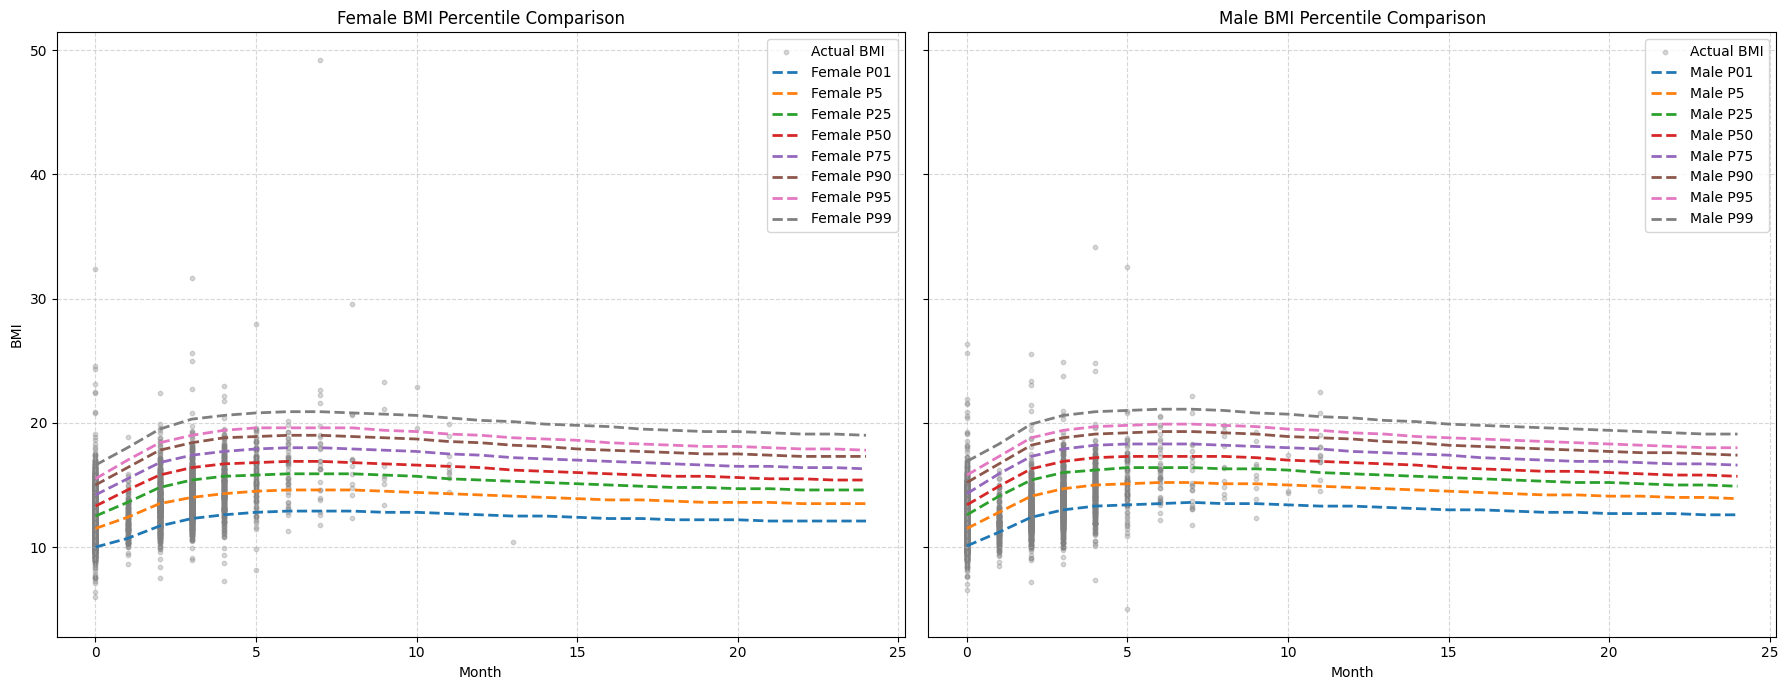

In [ ]:
result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_bmi_final_data.csv"
df_bmi = pd.read_csv(os.path.join(result_path, data_file))
df_male = pd.read_excel("./ref/tab_bmi_boys_p_0_2.xlsx")
df_female = pd.read_excel("./ref/tab_bmi_girls_p_0_2.xlsx")
print(df_bmi.shape)
plot_bmi_distribution(df_bmi, df_female, df_male)

성별별 data shape:: (7228, 96) (7423, 96)


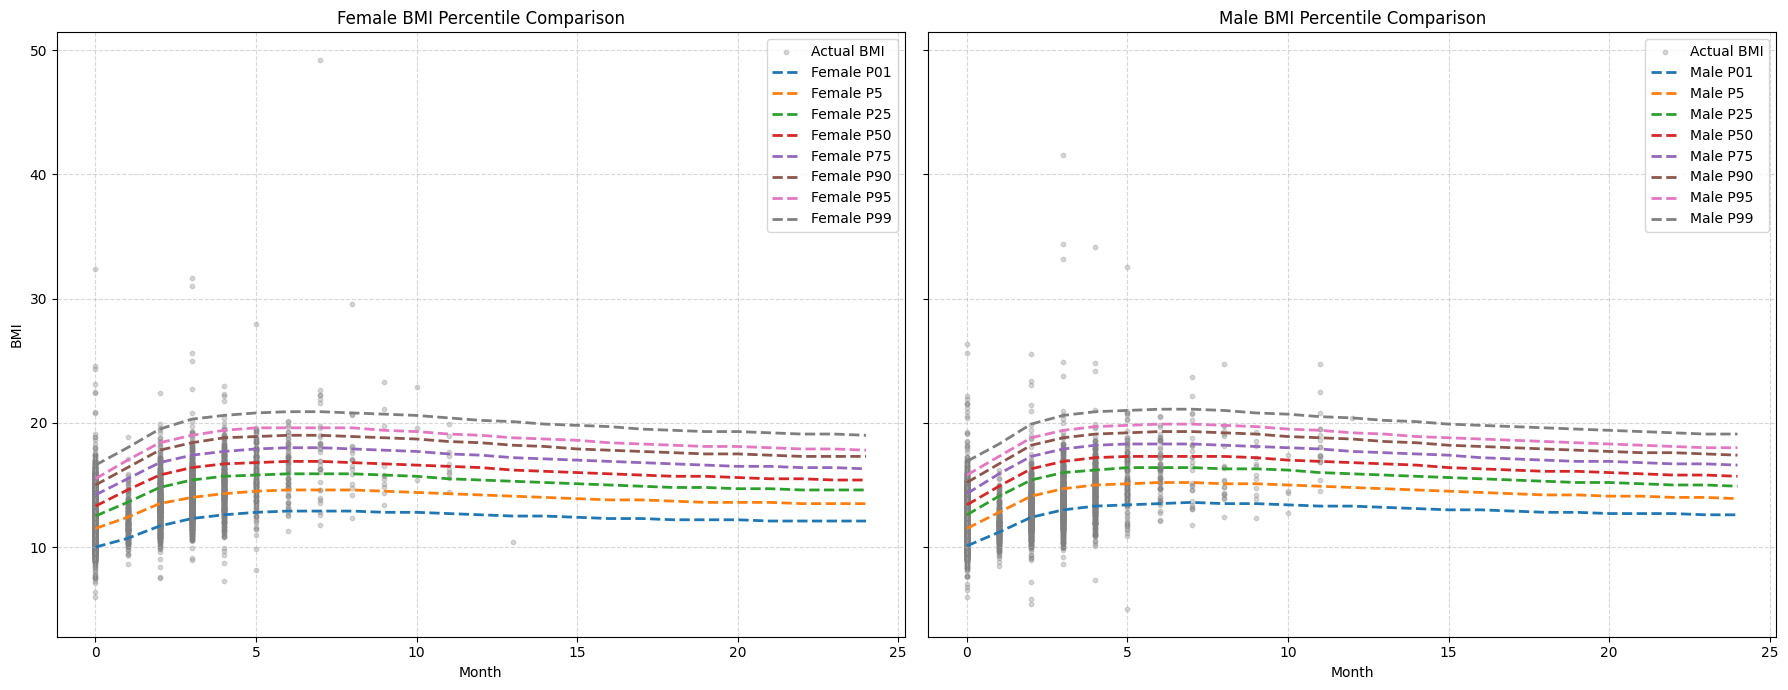

In [ ]:
# 교정주수 38주
result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_bmi.csv"
df_bmi = pd.read_csv(os.path.join(result_path, data_file))
df_male = pd.read_excel("./ref/tab_bmi_boys_p_0_2.xlsx")
df_female = pd.read_excel("./ref/tab_bmi_girls_p_0_2.xlsx")

plot_bmi_distribution(df_bmi, df_female, df_male)

41.0
성별별 data shape:: (7228, 99) (7423, 99)


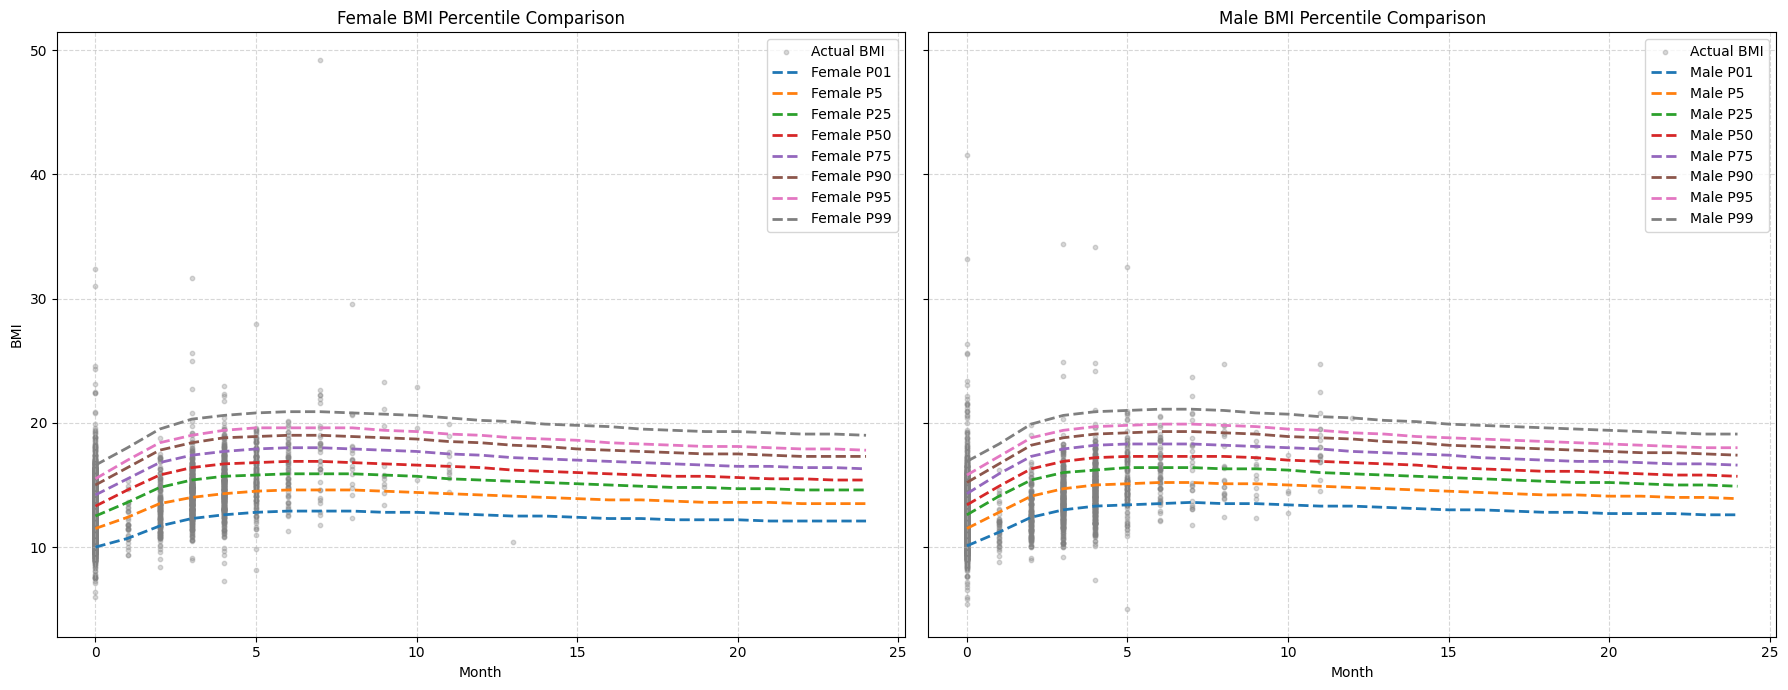

In [ ]:
df_bmi["corrected_aged"] = (df_bmi["gagew"] * 7 + df_bmi["gaged"] + df_bmi["stday"]) % 7
df_bmi["corrected_agew"] = (df_bmi["gagew"] * 7 + df_bmi["gaged"] + df_bmi["stday"]) // 7
df_bmi["corrected_age"] = (df_bmi["gagew"] * 7 + df_bmi["gaged"] + df_bmi["stday"])
df_bmi["corrected_agem"] = (df_bmi["gagew"] * 7 + df_bmi["gaged"] + df_bmi["stday"]) // 30.4375
print(df_bmi["corrected_agew"].quantile(0.76))
# df_bmi["dcd_age_day"] = df_bmi["gagew"] * 7 + df_bmi["gaged"] + df_bmi["stday"]
# df_bmi = df_bmi[(36 <= (df_bmi["corrected_agew"])) & ((df_bmi["corrected_agew"] ) <= 40)]
df_bmi["age_months"] = np.where(df_bmi["corrected_age"] < 42 * 7, 0, df_bmi["dcd_agem"])

plot_bmi_distribution(df_bmi, df_female, df_male)

# 연구대상 세분화

In [ ]:
result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_bmi.csv"
df_bmi = pd.read_csv(os.path.join(result_path, data_file))

In [ ]:
tmp = df_bmi[df_bmi["gagew"] < 28].copy() # 4600
tmp["dcd_age_day"] = tmp["gagew"] * 7 + tmp["gaged"] + tmp["stday"] # 퇴원시 교정 연령(일자 기준)

tmp["corrected_aged"] = (tmp["gagew"] * 7 + tmp["gaged"] + tmp["stday"]) % 7
tmp["corrected_agew"] = (tmp["gagew"] * 7 + tmp["gaged"] + tmp["stday"]) // 7
tmp["corrected_age"] = (tmp["gagew"] * 7 + tmp["gaged"] + tmp["stday"])
tmp["corrected_agem"] = (tmp["gagew"] * 7 + tmp["gaged"] + tmp["stday"]) // 30.4375
print(tmp["corrected_agew"].quantile(0.76))
# tmp["dcd_age_day"] = tmp["gagew"] * 7 + tmp["gaged"] + tmp["stday"]
tmp = tmp[(36 <= (tmp["corrected_agew"])) & ((tmp["corrected_agew"] ) <= 40)]
tmp["age_months"] = np.where(tmp["corrected_age"] < 42 * 7, 0, tmp["dcd_agem"])

tmp.shape

43.0


(2323, 100)

count    2323.000000
mean       85.390013
std        13.440984
min        57.000000
25%        75.000000
50%        85.000000
75%        95.000000
max       125.000000
Name: stday, dtype: float64
age_months
0.0    2323
Name: count, dtype: int64
성별별 data shape:: (1203, 100) (1120, 100)


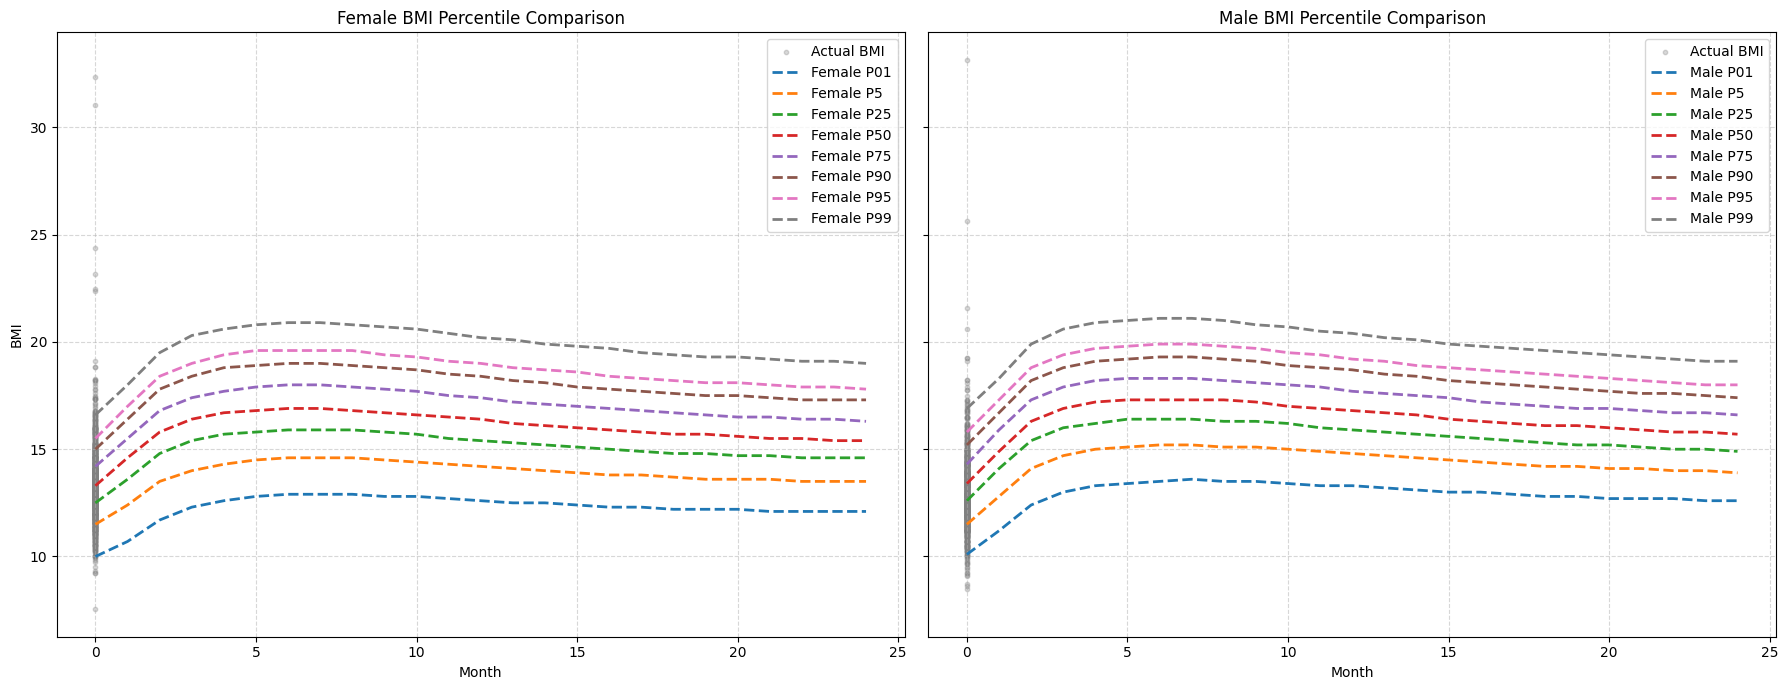

In [ ]:
print(tmp["stday"].describe())
print(tmp["age_months"].value_counts())
plot_bmi_distribution(tmp, df_female, df_male)

In [ ]:
tmp_36_40 = df_bmi.copy()
tmp_36_40["corrected_aged"] = (tmp_36_40["gagew"] * 7 + tmp_36_40["gaged"] + tmp_36_40["stday"]) % 7
tmp_36_40["corrected_agew"] = (tmp_36_40["gagew"] * 7 + tmp_36_40["gaged"] + tmp_36_40["stday"]) // 7
tmp_36_40["corrected_age"] = (tmp_36_40["gagew"] * 7 + tmp_36_40["gaged"] + tmp_36_40["stday"])
tmp_36_40["corrected_agem"] = (tmp_36_40["gagew"] * 7 + tmp_36_40["gaged"] + tmp_36_40["stday"]) // 30.4375
print(tmp_36_40["corrected_agew"].quantile(0.76))
# tmp_36_40["dcd_age_day"] = tmp_36_40["gagew"] * 7 + tmp_36_40["gaged"] + tmp_36_40["stday"]
tmp_36_40 = tmp_36_40[(36 <= (tmp_36_40["corrected_agew"])) & ((tmp_36_40["corrected_agew"] ) <= 40)]
tmp_36_40["age_months"] = np.where(tmp_36_40["corrected_age"] < 42 * 7, 0, tmp_36_40["dcd_agem"])
tmp_36_40.shape

41.0


(9913, 99)

In [ ]:
tmp_36_40[["dcd_aged", "corrected_age", "corrected_agew", "corrected_aged", "corrected_agem", "age_months"]].describe()

,dcd_aged,corrected_age,corrected_agew,corrected_aged,corrected_agem,age_months
count,9913.000000,9913.000000,9913.000000,9913.000000,9913.000000,9913.0
mean,59.406638,267.997175,37.862403,2.960355,8.297993,0.0
std,20.942752,9.111673,1.296543,1.990074,0.457399,0.0
min,12.000000,252.000000,36.000000,0.000000,8.000000,0.0
25%,44.000000,261.000000,37.000000,1.000000,8.000000,0.0
50%,58.000000,267.000000,38.000000,3.000000,8.000000,0.0
75%,74.000000,275.000000,39.000000,5.000000,9.000000,0.0
max,133.000000,286.000000,40.000000,6.000000,9.000000,0.0


In [ ]:
tmp_36_40[["corrected_age", "corrected_agew", "corrected_aged", "corrected_agem", "age_months"]]

,corrected_age,corrected_agew,corrected_aged,corrected_agem,age_months
1,269,38,3,8.0,1.0
2,267,38,1,8.0,1.0
4,253,36,1,8.0,2.0
6,253,36,1,8.0,1.0
7,265,37,6,8.0,1.0
...,...,...,...,...,...
14646,264,37,5,8.0,1.0
14647,271,38,5,8.0,2.0
14648,260,37,1,8.0,1.0
14649,276,39,3,9.0,2.0


count    4600.000000
mean      107.869348
std        41.398510
min        15.000000
25%        81.000000
50%        99.000000
75%       123.000000
max       365.000000
Name: stday, dtype: float64
age_months
0.0    9913
Name: count, dtype: int64
성별별 data shape:: (4812, 99) (5101, 99)


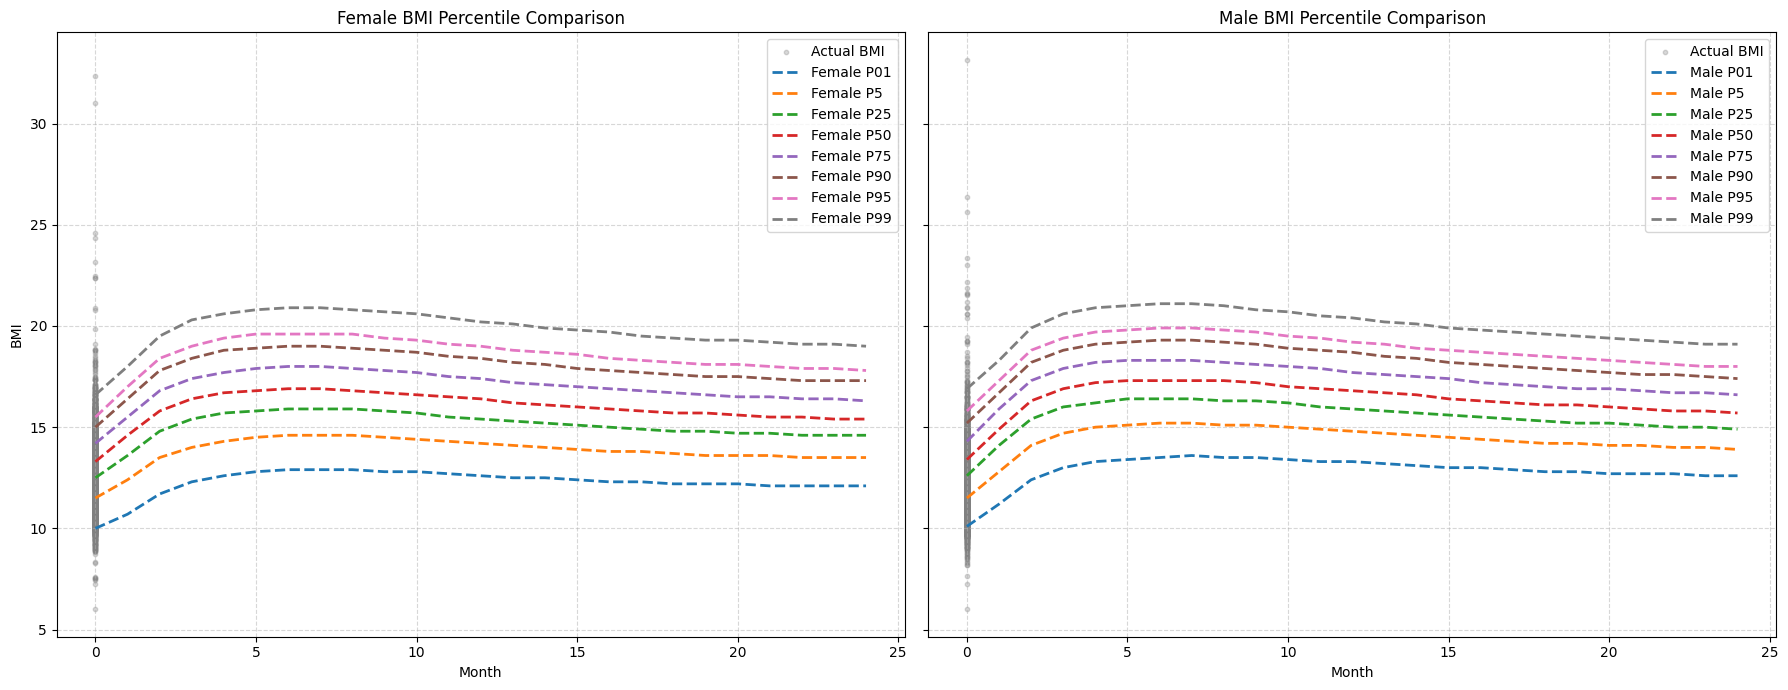

In [ ]:
print(tmp["stday"].describe())
print(tmp_36_40["age_months"].value_counts())
plot_bmi_distribution(tmp_36_40, df_female, df_male)

# 추가 변수 조사하기 (전체 데이터, 세분화 데이터 모두 확인하기)

In [231]:
# 설정 파일 및 데이터 불러오기
result_path = "F:/data/knn/" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_dataset.csv"
data = pd.read_csv(os.path.join(result_path, data_file))

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_67552\2985538052.py:4: DtypeWarning: Columns (22,90,102,110,111,117,132,139,162,201,205,215,217) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(result_path, data_file))


In [215]:
data_lt28 = data[data["gagew"] < 29].copy()
data_lt28.shape

(9211, 228)

BPD여부  (non vs. mild moderate severe 로 나누어서 변수 생성)

In [216]:
data["bdp_yn"] = 1
data.loc[data["bdp"].isin([2, 3, 4]), "bdp_yn"] = 2
data.loc[data["bdp"] == 5, "bdp_yn"] = np.nan
data["bdp_yn"].value_counts()

bdp_yn
2.0    8927
1.0    6747
Name: count, dtype: int64

In [217]:
data_lt28["bdp_yn"] = 1
data_lt28.loc[data_lt28["bdp"].isin([2, 3, 4]), "bdp_yn"] = 2
data_lt28.loc[data_lt28["bdp"] == 5, "bdp_yn"] = np.nan
data_lt28["bdp_yn"].value_counts()

bdp_yn
2.0    6388
1.0     742
Name: count, dtype: int64

출생 28일 이내 NEC grade 2 여부(NEC 진단 날짜가 나와 있는지 확인이 필요합니다)

In [218]:
# ntet, 1=없음|2=있음|3=모름
print(data[["ntetdt", "ntet"]].isnull().sum()) # ntetdt 869건 나머지 missing value
print(data[["ntet"]].value_counts())
# ntetdt가 아니면 뭘까?

ntetdt    17258
ntet          0
dtype: int64
ntet
1       16786
2        1193
3         148
Name: count, dtype: int64


In [230]:
# data[data["ntetdt"].notna()][["ntetdt", "ntet"]]
data[(data["ntet"] == 2) & (data["ntetdt"].notna())] 



,subjnm,sex_sys_val,birthdt,sex,subjno,mulg,bir1,bir2,bir3,bir4,...,death,car,neu,inf,gas,con,oth,tbrfeed,bdp_yn,seps_28
3507,ㄱㅇㄹ,1,2015-11-21,NaN,101-00069,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1
3539,ㅇㅅㄹ1,2,2015-07-04,NaN,073-00099,2,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1
3550,ㅇㅇㅎ,2,2015-08-29,NaN,073-00111,1,NaN,NaN,NaN,NaN,...,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3761,ㄱㅈㅎ,1,2015-10-26,NaN,020-00046,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1
3762,ㅎㅈㅈ,1,2015-11-20,NaN,020-00047,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18030,ㄱㅈㅇ2,2,2021-04-18,2.0,119-00244,2,NaN,2.0,NaN,NaN,...,4.0,NaN,NaN,NaN,1.0,NaN,NaN,2.0,NaN,1
18061,ㄱㅁㅎ2,2,2021-02-09,2.0,045-00224,2,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2
18090,ㅎㅇㅅㄹ,2,2021-10-03,2.0,106-00065,1,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,2
18109,ㄱㅅㅇ,1,2021-04-13,1.0,007-00305,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,1


출생 28일 이내 Sepsis 여부

In [229]:
# seps_category : 1=세균성 진균성 모두 해당|2= 세균성 1차,2차 날짜가 같은 경우|3= 세균성 1차를 안하고 2차만 하는 경우| 4=세균성만 진행
# seps_28 :
    # 세균성1st이 28이내 해당, 세균성 1st가 없어 세균성2nd가 28일이내 해당, 세균성이 없고 진균성1st이 28이내 해당, 진균성2nd가 28이내 해당
    
cols = ["birthdt", "bsfdt1", "bsfdt2", "bsfdt3", "fsfdt1", "fsfdt2"]
for col in cols :
    data[col] = pd.to_datetime(data[col])

seps_28_condition = [
    (data["bsfdt1"].notna()) & ((data["bsfdt1"] - data["birthdt"]).dt.days <= 28),
    (data["bsfdt2"].notna()) & ((data["bsfdt2"] - data["birthdt"]).dt.days <= 28),
    (data["bsfdt3"].notna()) & ((data["bsfdt3"] - data["birthdt"]).dt.days <= 28),
    (data["fsfdt1"].notna()) & ((data["fsfdt1"] - data["birthdt"]).dt.days <= 28),
    (data["fsfdt2"].notna()) & ((data["fsfdt2"] - data["birthdt"]).dt.days <= 28),
]
seps_28_value = [2, 2, 2, 2, 2]
data["seps_28"] = np.select(seps_28_condition, seps_28_value, default = 1)



seps_28
1    15556
2     2571
Name: count, dtype: int64

동맥관 개존 유무?  
ROP stage  

괴사성 장염으로 인한 최초 수술일, 수술 조사

In [235]:
data[["ntetdty", "ntetdty"]].isnull().sum()

ntetdty    17663
ntetdty    17663
dtype: int64

특발성 장천공, 수술일 조사

In [236]:
data[["iperr", "iperrdt"]].isnull().sum()

iperr          0
iperrdt    17818
dtype: int64

In [238]:
data["iperr"].value_counts()

iperr
1    17686
2      412
3       23
4        6
Name: count, dtype: int64

In [ ]:
import pandas as pd
import os

# 설정 파일 및 데이터 불러오기
result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_bmi_dataset_prep.csv"
data = pd.read_csv(os.path.join(result_path, data_file))

In [2]:
columns = ["birthdt", "ntetdty", "iperrdt", "phudstdt", "pdaddt", "acldt", "pmiodt", "avegftrdt"]
for i in columns :
    data[i] = pd.to_datetime(data[i])

KeyError: 'birthdt'

In [ ]:
data["28_ntet"] = (data["ntetdty"] - data["birthdt"]).dt.days
data["28_iperr"] = (data["iperrdt"] - data["birthdt"]).dt.days
data["28_phud"] = (data["phudstdt"] - data["birthdt"]).dt.days
data["28_pdad"] = (data["pdaddt"] - data["birthdt"]).dt.days
data["28_acl"] = (data["acldt"] - data["birthdt"]).dt.days
data["28_pmio"] = (data["pmiodt"] - data["birthdt"]).dt.days
data["28_avegftr"] = (data["avegftrdt"] - data["birthdt"]).dt.days

In [ ]:
print(data[data["28_ntet"] <= 28].shape)    # 139명
print(data[data["28_iperr"] <= 28].shape)   # 111명
print(data[data["28_phud"] <= 28].shape)    # 416명
print(data[data["28_pdad"] <= 28].shape)    # 3554명
print(data[data["28_acl"] <= 28].shape)     # 962명
print(data[data["28_pmio"] <= 28].shape)    # 0명
print(data[data["28_avegftr"] <= 28].shape) # 3명  

(139, 123)
(111, 123)
(416, 123)
(3554, 123)
(962, 123)
(0, 123)
(3, 123)


In [6]:
# 설정 파일 및 데이터 불러오기
result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "1_knn_bmi_corr.csv"
data = pd.read_csv(os.path.join(result_path, data_file))

print(data["28_phud"].value_counts())
print(data["28_pdad"].value_counts())
print(data["28_acl"].value_counts())

28_phud
1    9073
2     321
Name: count, dtype: int64
28_pdad
1    6287
2    3107
Name: count, dtype: int64
28_acl
1    8606
2     788
Name: count, dtype: int64


In [16]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from ssi_utils import bmi_zscore, WHO_bmi_zscore

# 설정 파일 및 데이터 불러오기
result_path = "F:/data/knn/knn_bmi/result" # "F:/data/knn/" # "F:/data/knn/knn_bmi/result"  # 예시 경로
data_file = "knn_bmi_dataset.csv"
data = pd.read_csv(os.path.join(result_path, data_file))

print(data[data["dcd_bmi_zscore"] >= 1].shape)
print(data[data["dcd_bmi_zscore"] > 1].shape)

(1057, 123)
(1057, 123)


In [21]:
data["_age_months"] = np.where(data["corrected_age"] < 43 * 7, 0, (data["corrected_age"] - (43 * 7) + 1) // 30.4375)
data["_dcd_bmi"] = (data["dcdwt"] / 1000) / (data["dcdht"] / 100) ** 2
    
data["_dcd_bmi_zscore"] = data.apply(
    lambda row: WHO_bmi_zscore(row["dcdwt"], row["dcdht"], row["_age_months"], row["sex_sys_val"]), 
    axis=1
)

In [22]:
data.loc[(-1 <= data['_dcd_bmi_zscore']) & (data['_dcd_bmi_zscore'] <= 1), '_label'] = 0
data.loc[data['_dcd_bmi_zscore'] > 1, '_label'] = 1
data.loc[data['_dcd_bmi_zscore'] < -1, '_label'] = 2

In [23]:
print(data[data["_dcd_bmi_zscore"] >= 1].shape)
print(data[data["_dcd_bmi_zscore"] > 1].shape)

(1484, 127)
(1484, 127)


In [20]:
print(data["label"].value_counts())
print(data["_label"].value_counts())

label
2.0    7106
0.0    4599
1.0    1057
Name: count, dtype: int64
_label
2.0    6417
0.0    4857
1.0    1488
Name: count, dtype: int64


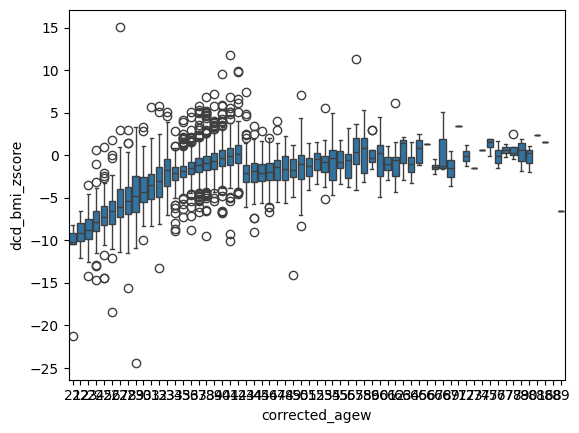

In [ ]:
figsize=(25, 25)
sns.boxplot(x = "corrected_agew", y = "dcd_bmi_zscore", data = data)
plt.show()